In [66]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [67]:
start=time.perf_counter()

In [68]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

In [69]:
from FPLPredictor import FPLPredictor

In [70]:
#add this info to a settings dict?
stats_current_gameweek = 20
picks_current_gameweek = 20
current_season = 20252026

In [71]:
# Load df from sql
df = db_creator.run_sql("""SELECT *
                        FROM playergw_transformed
                          """)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147904 entries, 0 to 147903
Columns: 430 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(425), object(5)
memory usage: 485.2+ MB


In [72]:
df[df['xgoals_p90sq_at']==0].pivot_table(index='season', values='xgoals_p90sq_at', aggfunc='count')

,xgoals_p90sq_at
season,
20222023.0,9145
20232024.0,2874
20242025.0,2992
20252026.0,2560


In [73]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>15)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132031,Bukayo Saka,16.0,11.0,Wolves,0.375133
132033,Bukayo Saka,17.0,3.0,Everton,0.371668
132035,Bukayo Saka,18.0,7.0,Brighton,0.369029
132037,Bukayo Saka,19.0,6.0,Aston Villa,0.369398
132039,Bukayo Saka,20.0,0.0,Bournemouth,0.367637
132041,Bukayo Saka,21.0,NaN,Liverpool,0.367637
132043,Bukayo Saka,22.0,NaN,Nott'm Forest,0.367637
132046,Bukayo Saka,23.0,NaN,Man Utd,0.367637
132048,Bukayo Saka,24.0,NaN,Leeds,0.367637
132050,Bukayo Saka,25.0,NaN,Sunderland,0.367637


In [74]:
cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

In [75]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [76]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['expected_goals']>0)

# First, check NaN summary to decide on threshold
if __name__ == "__main__":
    
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)
    
    temp_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 287 potential features:
Total rows: 38871

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35466    91.24            3405
                               tackles_p90sq_3      35466    91.24            3405
                           tackles_elo_p90sq_3      35466    91.24            3405
                               cbi_elo_p90sq_3      35466    91.24            3405
                                   cbi_p90sq_3      35466    91.24            3405
                        defensive_cont_p90sq_3      35466    91.24            3405
                    defensive_cont_elo_p90sq_3      35466    91.24            3405
                        recoveries_elo_p90sq_3      35466    91.24            3405
                        recoveries_elo_p90sq_5      35440    91.17            3431
                           tackles_elo_p90sq_5      35440    91

In [77]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [78]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [79]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [80]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 603/7365

Training Set Performance:
R² Score: 0.8976
RMSE: 10.2993
MAE: 8.2982

Test Set Performance:
R² Score: 0.4039
RMSE: 24.8291
MAE: 19.7568

Top 20 Feature Importances:
                               feature  importance
                             minutes_3    0.143789
                      team_elo_p90sq_3    0.061748
              opp_team_elo_elo_p90sq_3    0.042824
                  opp_team_elo_p90sq_5    0.023107
                         minutes_elo_3    0.020156
                       xassists_elo_10    0.018464
                  opp_team_elo_p90sq_3    0.016552
                             minutes_5    0.015506
            defensive_cont_elo_p90sq_3    0.010992
                        bonus_p90sq_at    0.010313
                  team_elo_elo_p90sq_3    0.010009
                       opp_team_elo_10    0.008222
 xgoal_involvements_x_defensive_cont_3    0.008122
                          opp_team_elo    0.008072
xgoal_involvements_x_defensive_cont_at    0

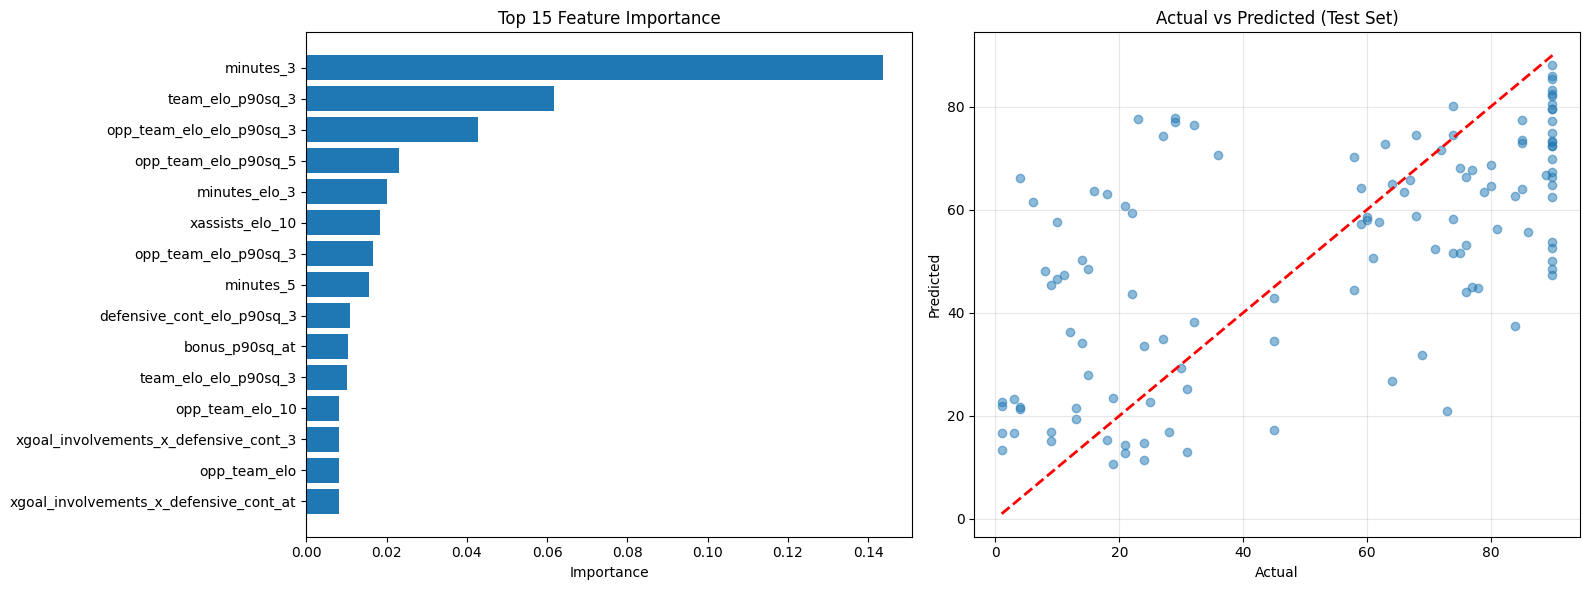

Cleaned df size: 2479/27404

Training Set Performance:
R² Score: 0.8167
RMSE: 13.3282
MAE: 10.8602

Test Set Performance:
R² Score: 0.3565
RMSE: 25.4653
MAE: 19.9630

Top 20 Feature Importances:
                                   feature  importance
                                 minutes_3    0.315987
                                    bps_10    0.027244
                                bps_elo_10    0.015695
                                 minutes_5    0.014245
                                minutes_10    0.012788
                             minutes_elo_3    0.011110
                                 bps_elo_3    0.009405
                              opp_team_elo    0.007835
                            opp_team_elo_5    0.007246
                      opp_team_elo_p90sq_5    0.007096
                         team_elo_p90sq_10    0.007000
                                     bps_3    0.006343
                           opp_team_elo_10    0.005941
                   goals_conceded_p

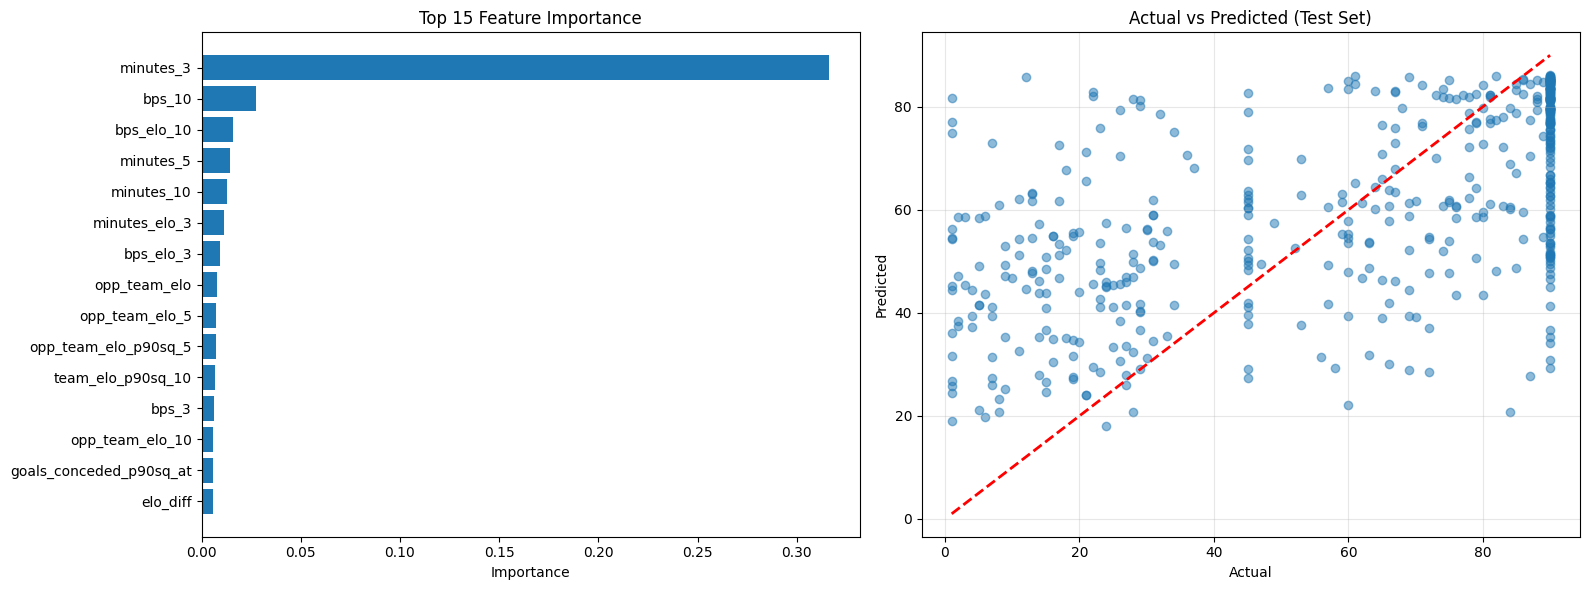

Cleaned df size: 1739/19537

Training Set Performance:
R² Score: 0.8118
RMSE: 12.3066
MAE: 8.6892

Test Set Performance:
R² Score: 0.4217
RMSE: 20.3837
MAE: 14.1623

Top 20 Feature Importances:
                    feature  importance
                  minutes_3    0.084525
   opp_team_elo_elo_p90sq_3    0.053849
       opp_team_elo_p90sq_3    0.047720
           team_elo_p90sq_3    0.027757
   opp_team_elo_elo_p90sq_5    0.027552
       team_elo_elo_p90sq_3    0.020906
      xgoals_conceded_elo_3    0.018982
              minutes_elo_3    0.018982
               opp_team_elo    0.012877
                bps_p90sq_3    0.012290
                   elo_diff    0.009800
xgoals_conceded_elo_p90sq_5    0.009511
 defensive_cont_elo_p90sq_3    0.009035
            opp_team_elo_10    0.008952
         total_points_elo_3    0.008086
        total_points_p90_10    0.008020
xgoals_conceded_elo_p90sq_3    0.007771
             opp_team_elo_3    0.007298
                  bps_elo_3    0.007099
     d

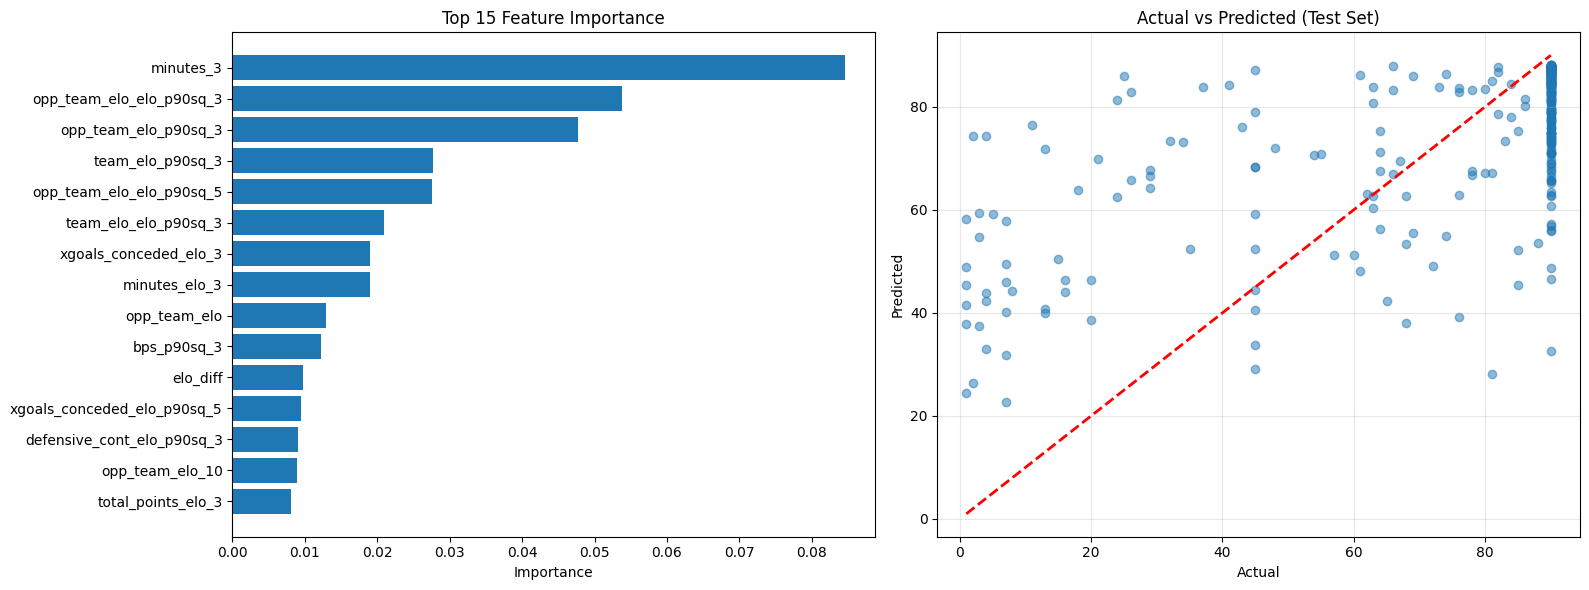

Cleaned df size: 349/4028

Training Set Performance:
R² Score: 0.8379
RMSE: 3.5860
MAE: 1.0033

Test Set Performance:
R² Score: 0.0000
RMSE: 5.5814
MAE: 1.8883

Top 20 Feature Importances:
                  feature  importance
       saves_elo_p90sq_10    0.121949
          bps_elo_p90sq_3    0.066543
    opp_team_elo_p90sq_at    0.034916
        xgoals_conceded_3    0.033218
     opp_team_elo_p90sq_5    0.031329
           opp_team_elo_5    0.026201
      total_points_p90_10    0.025125
         bps_elo_p90sq_10    0.019459
      total_points_elo_10    0.018810
           bps_elo_p90_10    0.018364
           opp_team_elo_3    0.017127
          cbi_elo_p90sq_3    0.017034
    opp_team_elo_p90sq_10    0.016828
                bps_elo_3    0.016457
    xgoals_conceded_elo_3    0.016153
xgoals_conceded_elo_p90_5    0.014969
total_points_elo_p90sq_10    0.014013
               bps_elo_10    0.013701
  total_points_elo_p90_10    0.013671
               team_elo_5    0.012780


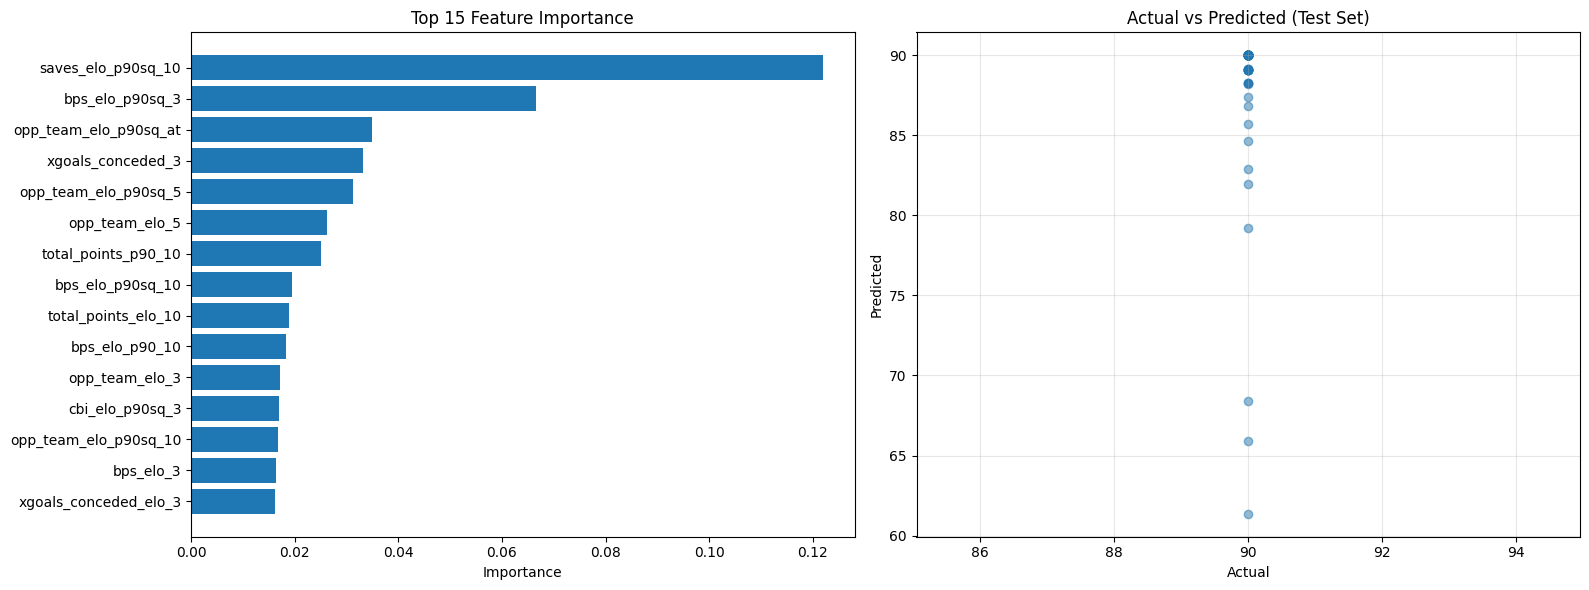

In [81]:
mins_filter = (df['player_season_minutes_total']>0)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 351/4407

Training Set Performance:
R² Score: 0.8238
RMSE: 0.1843
MAE: 0.1360

Test Set Performance:
R² Score: -0.0208
RMSE: 0.4988
MAE: 0.3965

Top 20 Feature Importances:
                       feature  importance
                      xgoals_5    0.027730
                bonus_p90sq_at    0.027295
               xassists_elo_10    0.027238
                  opp_team_elo    0.019899
                xassists_elo_5    0.015709
             minutes_elo_p90_3    0.014663
                      elo_diff    0.014059
          xgoal_involvements_5    0.012619
   goals_conceded_elo_p90sq_10    0.012542
      xgoals_conceded_p90sq_at    0.011950
               tackles_p90sq_3    0.011771
                  xgoals_p90_5    0.010255
         total_points_p90sq_at    0.010006
             minutes_elo_p90_5    0.009613
           tackles_elo_p90sq_3    0.009174
             xgoals_conceded_3    0.008987
                      xgoals_3   

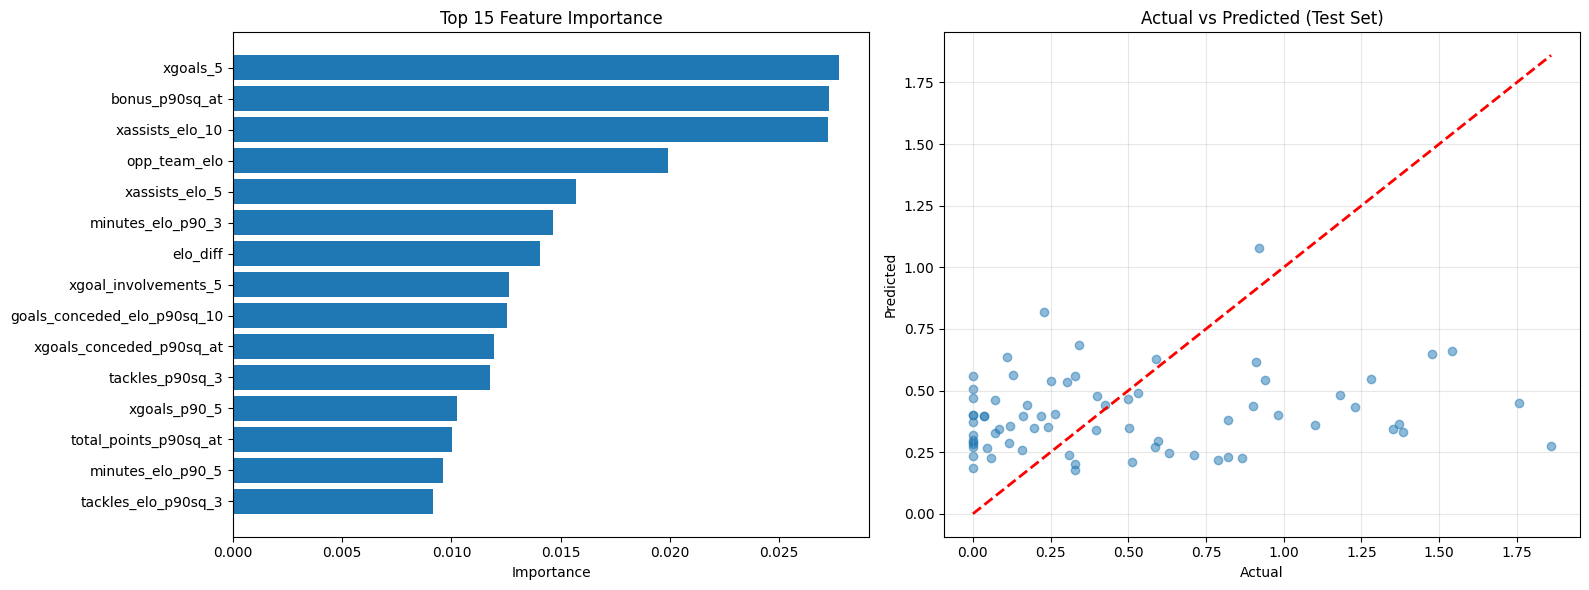

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 1639/18323

Training Set Performance:
R² Score: 0.7144
RMSE: 0.1263
MAE: 0.0928

Test Set Performance:
R² Score: 0.0258
RMSE: 0.2579
MAE: 0.1669

Top 20 Feature Importances:
                     feature  importance
        opp_team_elo_p90sq_3    0.075995
               xgoals_elo_10    0.038278
                xgoals_elo_5    0.029809
              opp_team_elo_3    0.018168
       goals_conceded_p90_10    0.015902
                opp_team_elo    0.013093
              opp_team_elo_5    0.012218
xgoal_involvements_elo_p90_5    0.011084
                  team_elo_5    0.011071
           xassists_p90sq_at    0.009733
            xgoals_elo_p90_5    0.009383
          xgoals_elo_p90sq_5    0.009360
              xgoals_p90sq_5    0.009211
        opp_team_elo_p90sq_5    0.009081
       clean_sheets_p90sq_at    0.008764
              bonus_p90sq_at    0.008344
                 cbi_p90sq_5    0.008242
     goals_conceded_p90sq

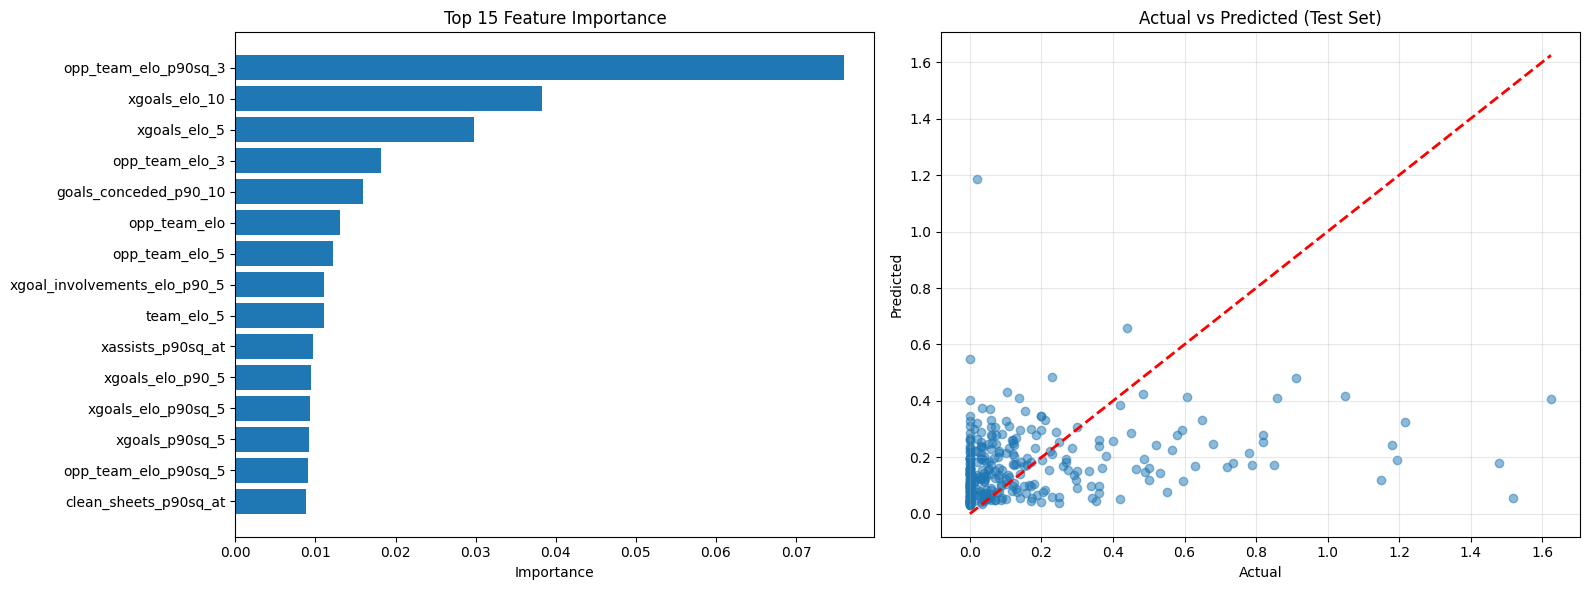

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 1415/16141

Training Set Performance:
R² Score: 0.6365
RMSE: 0.0710
MAE: 0.0467

Test Set Performance:
R² Score: -0.0952
RMSE: 0.1504
MAE: 0.0828

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.044655
                                bps_elo_10    0.033885
                      clean_sheets_p90sq_3    0.031553
                            bps_elo_p90_10    0.022115
                              opp_team_elo    0.018864
                                 bps_elo_5    0.018746
                                 bps_elo_3    0.012737
                     goals_scored_p90sq_at    0.012483
                  xgoals_conceded_p90sq_at    0.012281
                      team_elo_elo_p90sq_3    0.012070
                        bonus_elo_p90sq_10    0.011983
                  xgoals_conceded_p90sq_10    0.011821
                              bps_p90sq_at    0

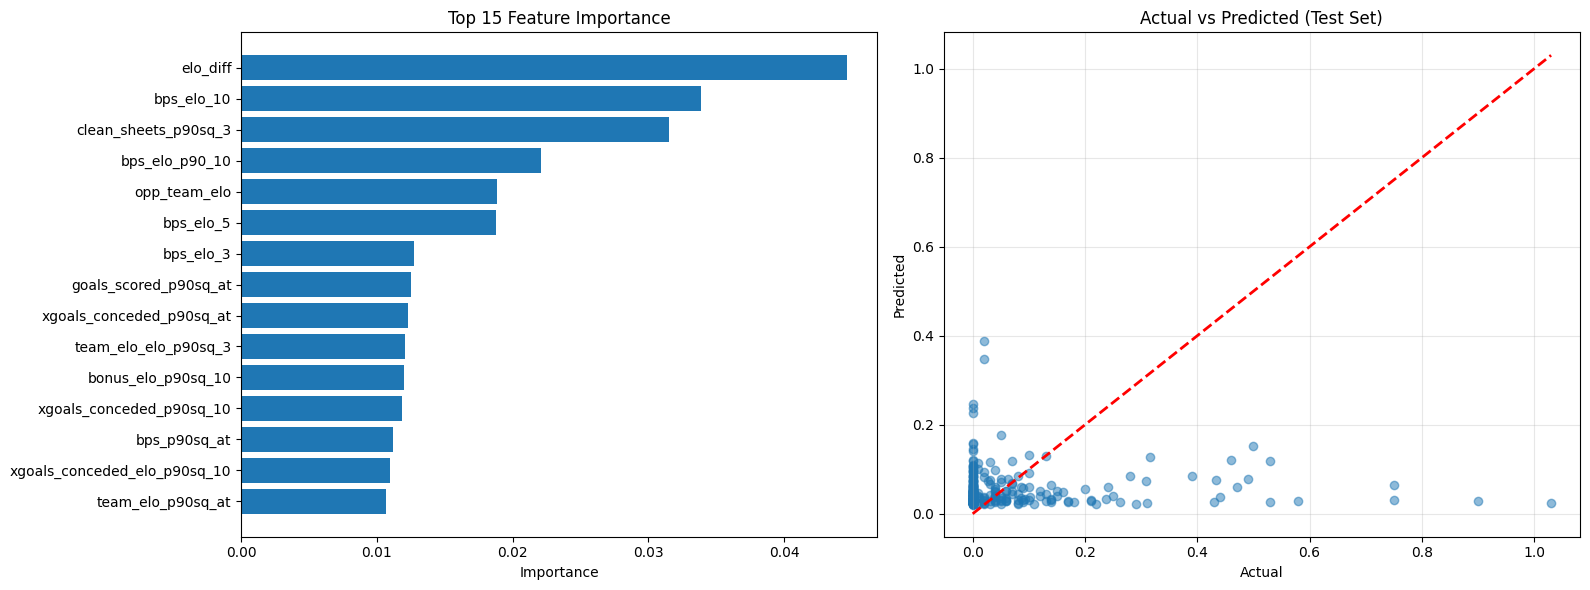

In [82]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 351/4404

Training Set Performance:
R² Score: 0.7950
RMSE: 0.0379
MAE: 0.0258

Test Set Performance:
R² Score: -0.4526
RMSE: 0.0628
MAE: 0.0465

Top 20 Feature Importances:
                      feature  importance
        opp_team_elo_p90sq_10    0.062647
                     elo_diff    0.050396
               opp_team_elo_5    0.028414
xgoal_involvements_elo_p90_10    0.021878
                    bps_elo_3    0.017196
                 opp_team_elo    0.014264
     xgoals_conceded_p90sq_at    0.013393
         tackles_elo_p90sq_10    0.013084
        goals_conceded_elo_10    0.013005
            goals_conceded_10    0.013005
               bonus_p90sq_at    0.012701
       xgoals_conceded_p90_10    0.012066
              opp_team_elo_10    0.011443
       total_points_elo_p90_5    0.011185
                        bps_3    0.010222
          tackles_elo_p90sq_3    0.010091
     goals_scored_elo_p90sq_5    0.009875
      

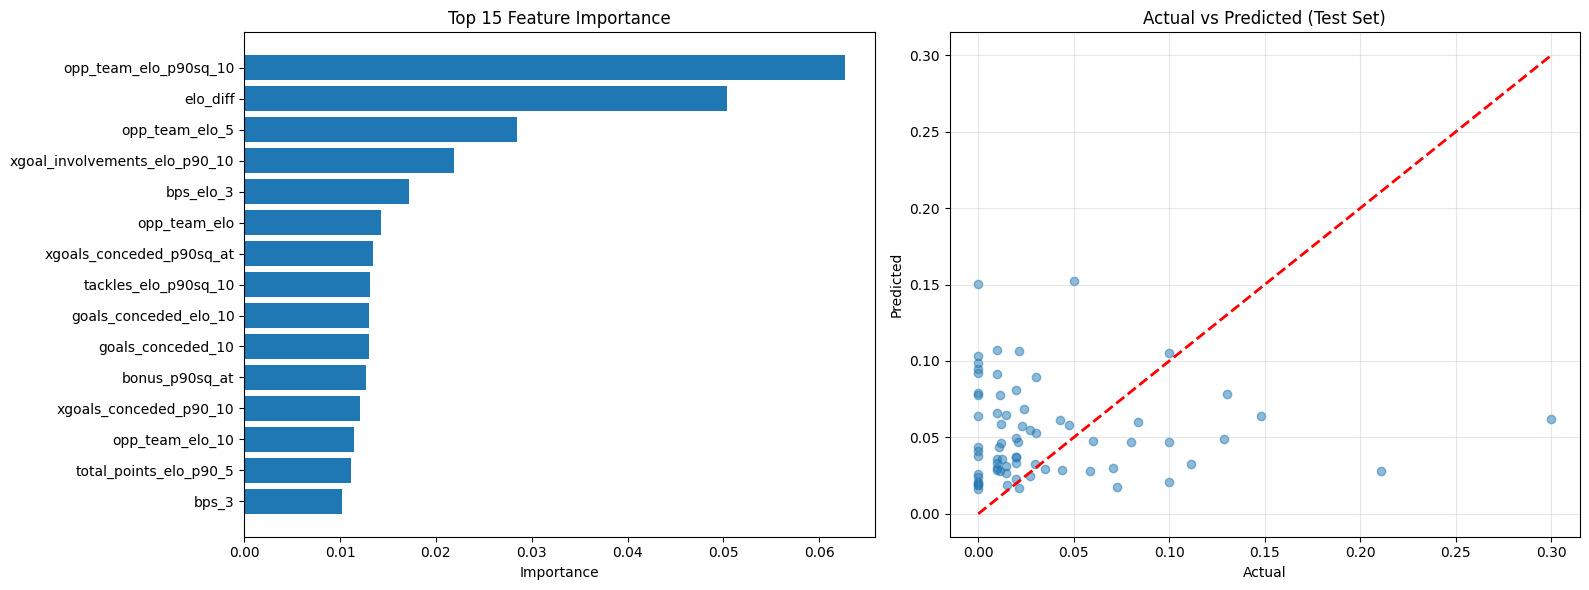

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 1639/18305

Training Set Performance:
R² Score: 0.7225
RMSE: 0.0832
MAE: 0.0626

Test Set Performance:
R² Score: -0.0230
RMSE: 0.1548
MAE: 0.1095

Top 20 Feature Importances:
                                      feature  importance
                          xassists_elo_p90_10    0.042393
                                     elo_diff    0.023226
                    xgoal_involvements_elo_10    0.022134
xgoal_involvements_x_defensive_cont_elo_p90_5    0.020166
                        xassists_elo_p90sq_10    0.019588
                                 opp_team_elo    0.019567
                                  xassists_10    0.017728
                           xassists_elo_p90_5    0.015689
                xgoal_involvements_elo_p90_10    0.013726
   xgoal_involvements_x_defensive_cont_p90_at    0.013301
                              xassists_p90_10    0.013100
                                   bps_p90_10    0.011584
      

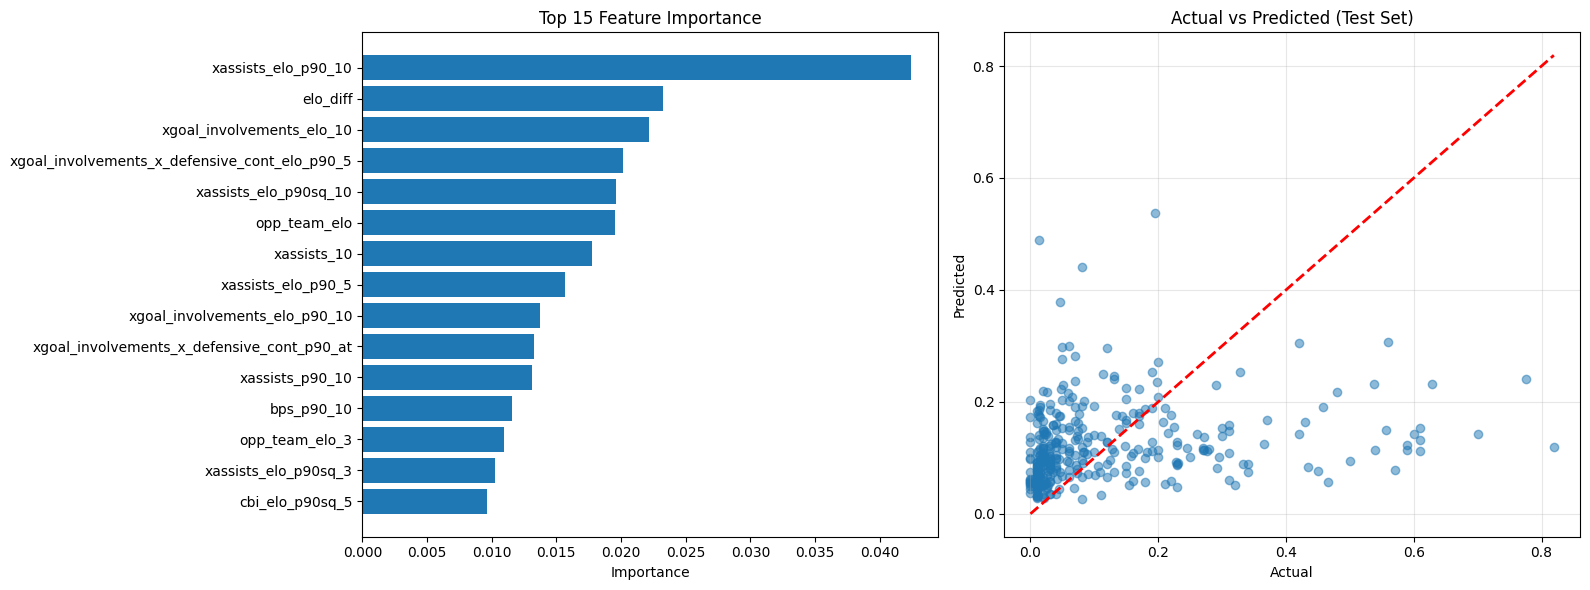

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 1414/16111

Training Set Performance:
R² Score: 0.7207
RMSE: 0.0556
MAE: 0.0379

Test Set Performance:
R² Score: -0.0009
RMSE: 0.0977
MAE: 0.0622

Top 20 Feature Importances:
                feature  importance
        xassists_p90_10    0.041237
           opp_team_elo    0.033280
   tackles_elo_p90sq_10    0.028094
      xassists_p90sq_at    0.024750
      xgoals_conceded_3    0.017092
            xassists_10    0.016820
       tackles_p90sq_10    0.014783
      team_elo_p90sq_at    0.014745
  xassists_elo_p90sq_10    0.013844
         total_points_5    0.013640
            team_elo_10    0.013392
  goals_scored_p90sq_at    0.011783
               elo_diff    0.011342
         bonus_p90sq_at    0.010935
        tackles_p90sq_5    0.010490
      xassists_p90sq_10    0.010399
recoveries_elo_p90sq_10    0.009777
              bps_elo_3    0.009462
        opp_team_elo_10    0.009376
         team_elo_elo_5    0.008685


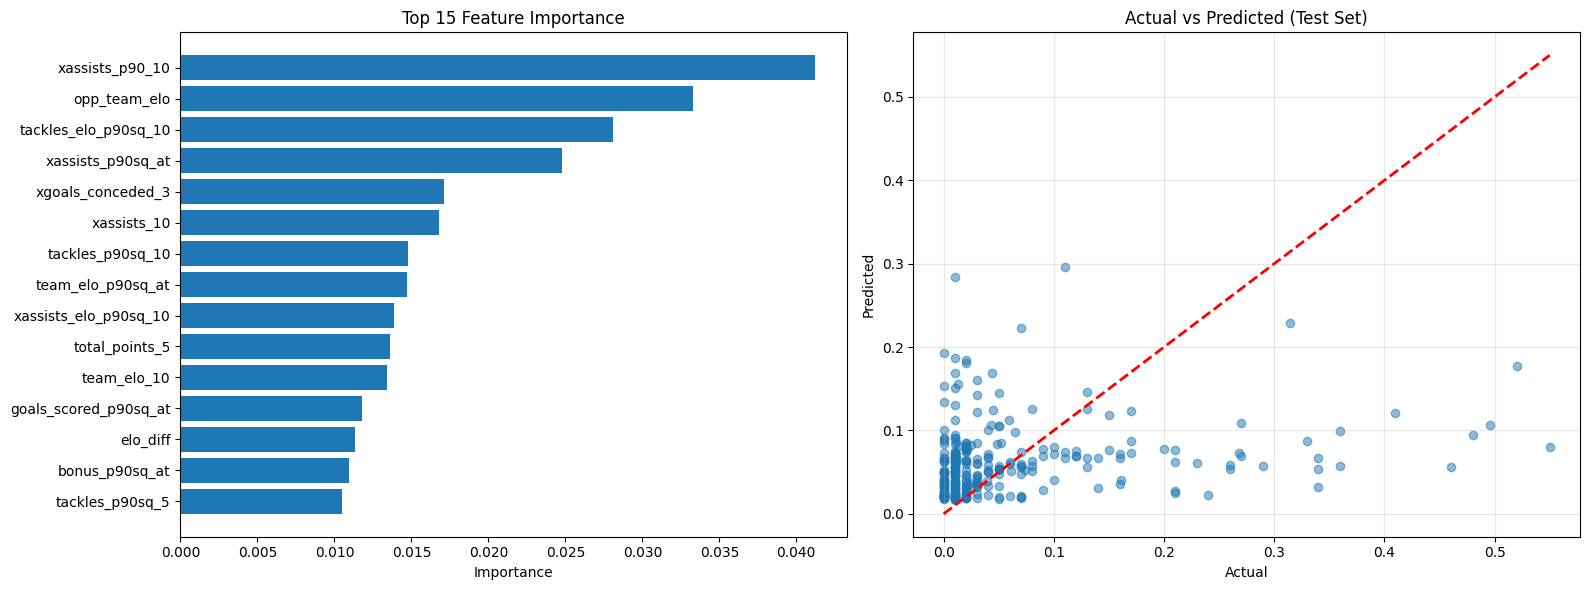

In [83]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 351/4404

Training Set Performance:
R² Score: 0.8275
RMSE: 0.3471
MAE: 0.2883

Test Set Performance:
R² Score: 0.1173
RMSE: 0.7572
MAE: 0.5847

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.094760
                              opp_team_elo    0.045240
                            opp_team_elo_3    0.027750
                      opp_team_elo_p90sq_3    0.027041
                            opp_team_elo_5    0.014494
xgoal_involvements_x_defensive_cont_p90_at    0.010490
                    defensive_cont_p90sq_3    0.010079
                        xgoals_conceded_10    0.009922
                         xgoals_conceded_3    0.009029
                          team_elo_p90sq_3    0.008514
                          team_elo_p90sq_5    0.008440
                      opp_team_elo_p90sq_5    0.008401
              xgoals_conceded_elo_p90sq_

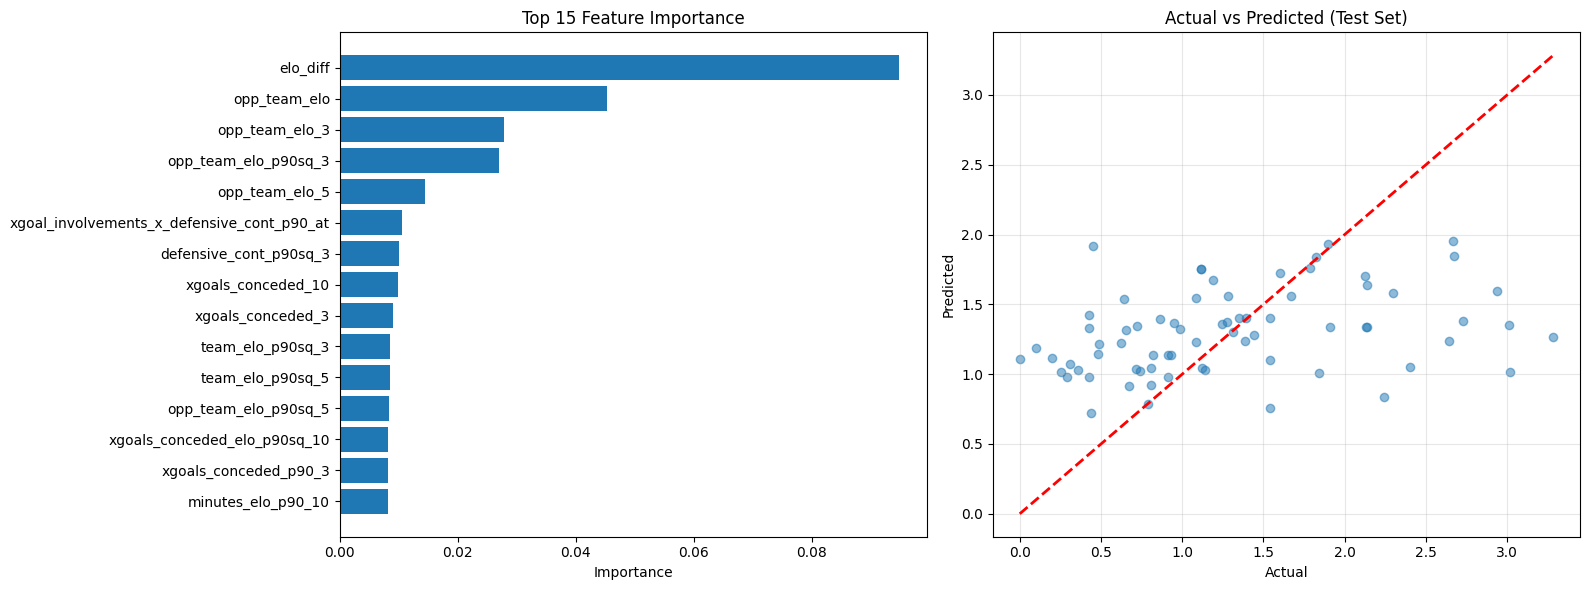

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 1639/18305

Training Set Performance:
R² Score: 0.8109
RMSE: 0.3483
MAE: 0.2819

Test Set Performance:
R² Score: 0.4250
RMSE: 0.5849
MAE: 0.4536

Top 20 Feature Importances:
                     feature  importance
                    elo_diff    0.159604
                opp_team_elo    0.069819
              opp_team_elo_3    0.068683
                    team_elo    0.041024
              opp_team_elo_5    0.027983
             opp_team_elo_10    0.026970
                  team_elo_5    0.017308
             team_elo_elo_10    0.014900
        minutes_elo_p90sq_10    0.014883
                 team_elo_10    0.014571
                  team_elo_3    0.014054
         opp_team_elo_elo_10    0.010525
              team_elo_elo_3    0.008682
          opp_team_elo_elo_3    0.007975
              team_elo_elo_5    0.007765
         minutes_elo_p90sq_3    0.007715
         minutes_elo_p90sq_5    0.007674
          opp_t

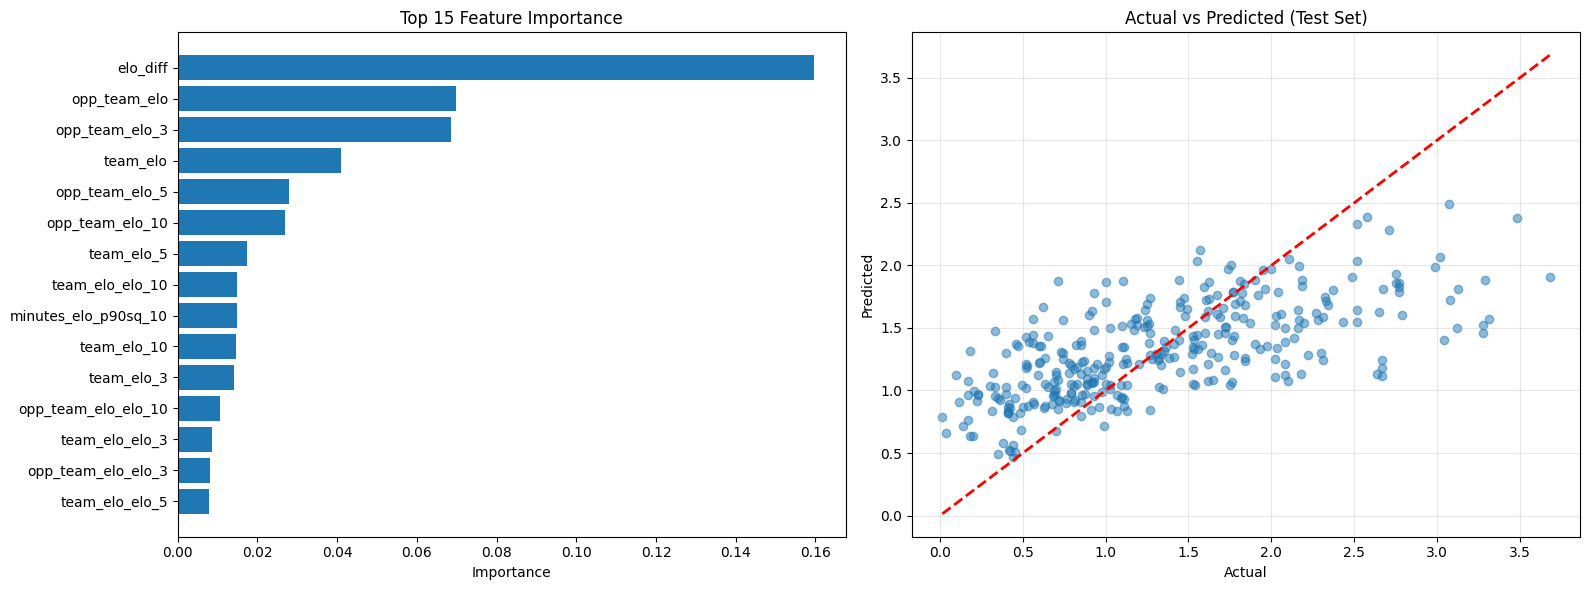

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 1414/16111

Training Set Performance:
R² Score: 0.8327
RMSE: 0.3335
MAE: 0.2637

Test Set Performance:
R² Score: 0.3947
RMSE: 0.6571
MAE: 0.5057

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.165838
             opp_team_elo_3    0.072857
               opp_team_elo    0.042159
                   team_elo    0.022275
            opp_team_elo_10    0.021964
             opp_team_elo_5    0.021732
                team_elo_10    0.021250
                 team_elo_5    0.015773
             team_elo_elo_5    0.015029
         opp_team_elo_elo_5    0.014084
                 team_elo_3    0.013145
            team_elo_elo_10    0.011598
     goals_conceded_p90sq_3    0.010203
 goals_conceded_elo_p90sq_3    0.010104
        minutes_elo_p90sq_5    0.008253
xgoals_conceded_elo_p90sq_3    0.008089
    xgoals_conceded_p90sq_5    0.007677
             team_elo_elo_3    0.

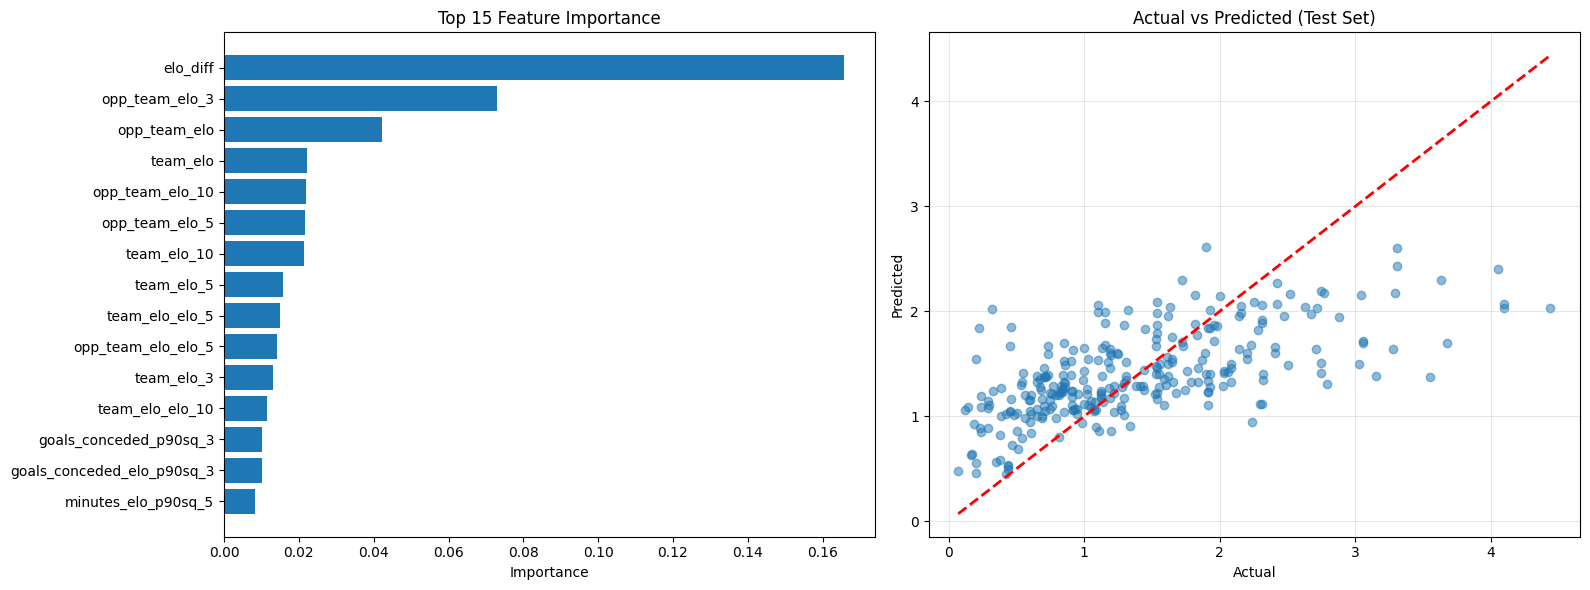

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 346/3941

Training Set Performance:
R² Score: 0.8440
RMSE: 0.3179
MAE: 0.2523

Test Set Performance:
R² Score: -0.1674
RMSE: 0.8995
MAE: 0.7313

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.113428
               opp_team_elo    0.044179
          team_elo_p90sq_at    0.024845
             opp_team_elo_3    0.021547
xgoals_conceded_elo_p90sq_3    0.019401
             saves_p90sq_at    0.016838
                team_elo_10    0.015496
             minutes_elo_10    0.015178
                   team_elo    0.014325
         recoveries_p90sq_3    0.013752
             opp_team_elo_5    0.012014
          saves_elo_p90sq_3    0.011178
    goals_conceded_p90sq_at    0.010467
    xgoals_conceded_p90sq_3    0.010267
            opp_team_elo_10    0.010174
         xgoals_conceded_10    0.009839
xgoals_conceded_elo_p90sq_5    0.009630
         recoveries_p90sq_5    0.00

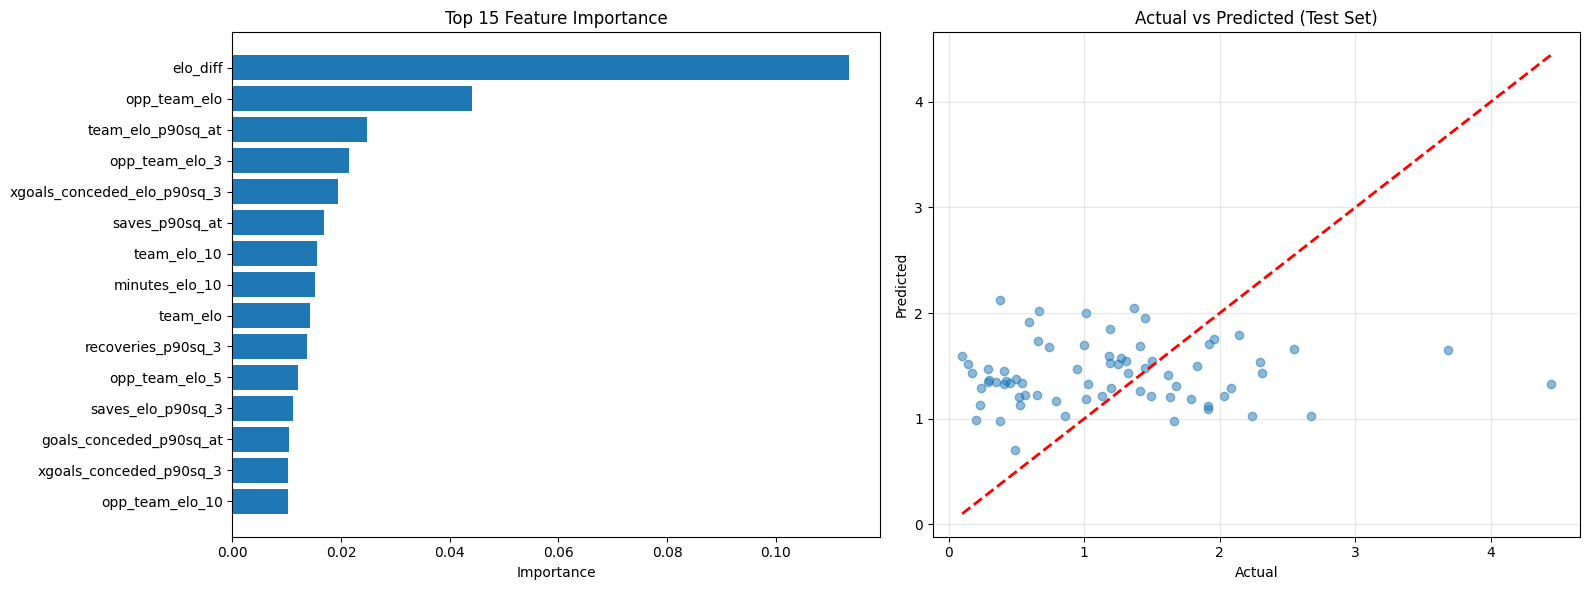

In [84]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 351/4404

Training Set Performance:
R² Score: 0.7817
RMSE: 8.1037
MAE: 6.4707

Test Set Performance:
R² Score: -0.1010
RMSE: 20.5163
MAE: 14.6420

Top 20 Feature Importances:
                                      feature  importance
                            minutes_elo_p90_3    0.041068
                            minutes_elo_p90_5    0.025273
                              xassists_elo_10    0.023707
                         xgoal_involvements_5    0.020671
                              xassists_p90_10    0.017575
                                  team_elo_10    0.016384
                   xgoals_conceded_elo_p90_10    0.014516
                      clean_sheets_elo_p90_10    0.013045
                                     xgoals_5    0.011690
                           minutes_elo_p90_10    0.011539
xgoal_involvements_x_defensive_cont_elo_p90_3    0.011388
                               opp_team_elo_3    0.010730
                  

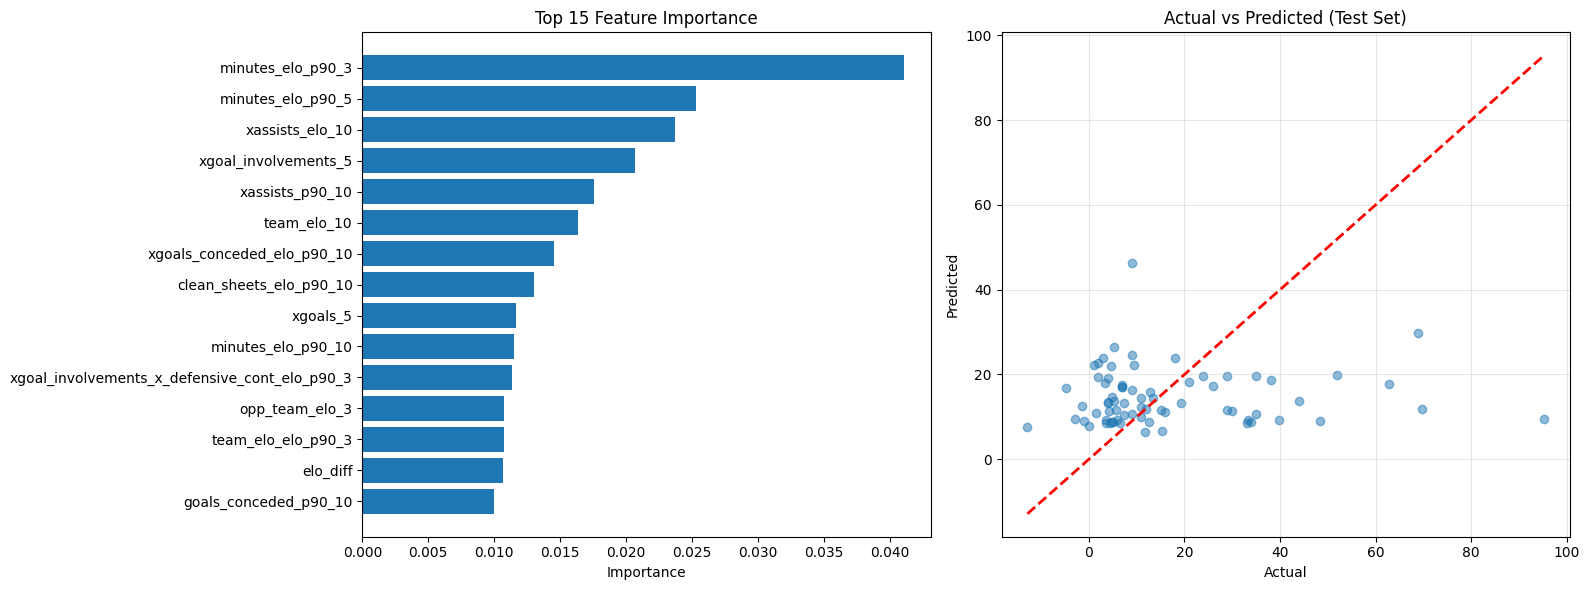

target=bps_per90, MID_bps_predictor
Cleaned df size: 1639/18305

Training Set Performance:
R² Score: 0.6132
RMSE: 7.1316
MAE: 5.5874

Test Set Performance:
R² Score: -0.0343
RMSE: 12.2576
MAE: 9.3595

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.031818
                              opp_team_elo    0.021669
                  clean_sheets_elo_p90sq_5    0.016942
                            bonus_p90sq_at    0.013925
                           cbi_elo_p90sq_3    0.011861
                      opp_team_elo_p90sq_3    0.011647
                        xassists_elo_p90_3    0.010823
                defensive_cont_elo_p90sq_5    0.010648
                     opp_team_elo_p90sq_10    0.010253
                                xassists_3    0.009829
xgoal_involvements_x_defensive_cont_p90_10    0.009252
                    defensive_cont_p90sq_3    0.008867
                             minutes_elo_3    0.008811
 

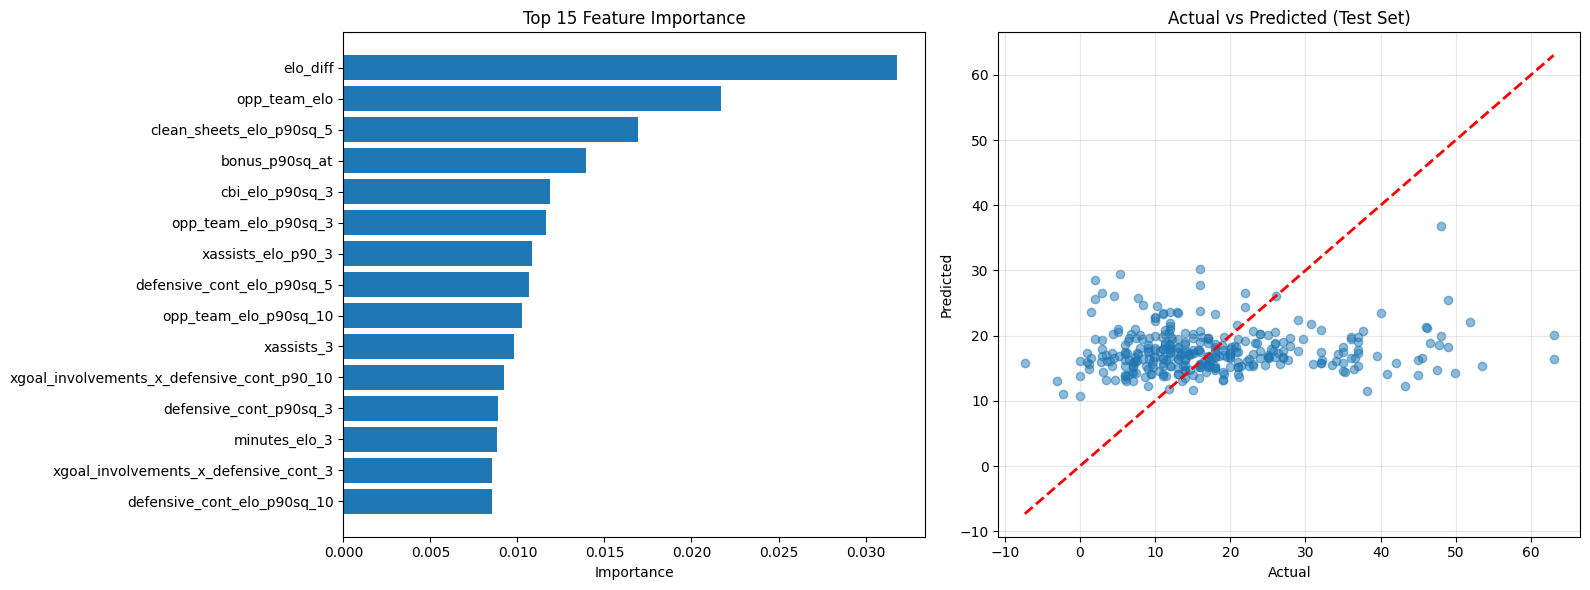

target=bps_per90, DEF_bps_predictor
Cleaned df size: 1414/16111

Training Set Performance:
R² Score: 0.7618
RMSE: 6.2156
MAE: 5.0421

Test Set Performance:
R² Score: 0.2421
RMSE: 9.8904
MAE: 7.7646

Top 20 Feature Importances:
                     feature  importance
                    elo_diff    0.130843
             opp_team_elo_10    0.037335
              opp_team_elo_5    0.019707
                opp_team_elo    0.016733
        goals_conceded_elo_3    0.010805
                       bps_3    0.010683
              opp_team_elo_3    0.010443
                   bps_elo_3    0.009713
         minutes_elo_p90sq_3    0.009410
                  bps_elo_10    0.009170
       xgoals_conceded_p90_3    0.008405
                bps_p90sq_at    0.008133
        opp_team_elo_p90sq_3    0.008053
 xgoals_conceded_elo_p90sq_5    0.008022
         minutes_elo_p90sq_5    0.007832
              team_elo_elo_5    0.007819
    xgoals_conceded_p90sq_at    0.007718
      goals_conceded_p90sq_3    0.0

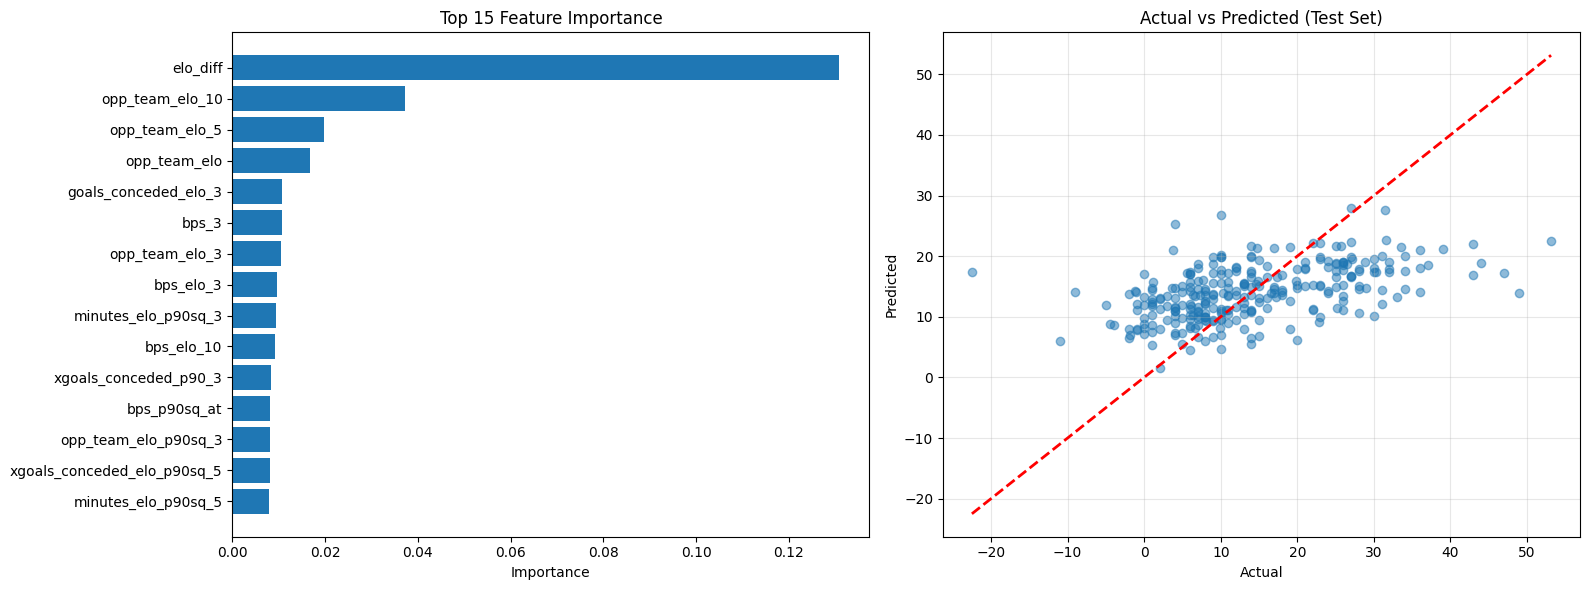

target=bps_per90, GK_bps_predictor
Cleaned df size: 346/3941

Training Set Performance:
R² Score: 0.8220
RMSE: 4.3760
MAE: 3.5038

Test Set Performance:
R² Score: -0.0564
RMSE: 10.7707
MAE: 8.7441

Top 20 Feature Importances:
                    feature  importance
   xgoals_conceded_p90sq_10    0.025543
                   team_elo    0.024681
                   elo_diff    0.022304
               opp_team_elo    0.019454
    xgoals_conceded_p90sq_3    0.018530
       goals_conceded_elo_3    0.014769
      goals_conceded_elo_10    0.014292
       goals_conceded_elo_5    0.013747
             opp_team_elo_3    0.013457
     total_points_elo_p90_5    0.013068
   total_points_elo_p90sq_5    0.012888
           bps_elo_p90sq_10    0.012887
          bonus_elo_p90sq_3    0.012571
             opp_team_elo_5    0.012457
         recoveries_p90sq_3    0.011827
       opp_team_elo_p90sq_5    0.011469
   total_points_elo_p90sq_3    0.011295
xgoals_conceded_elo_p90sq_5    0.010992
xgoals_concede

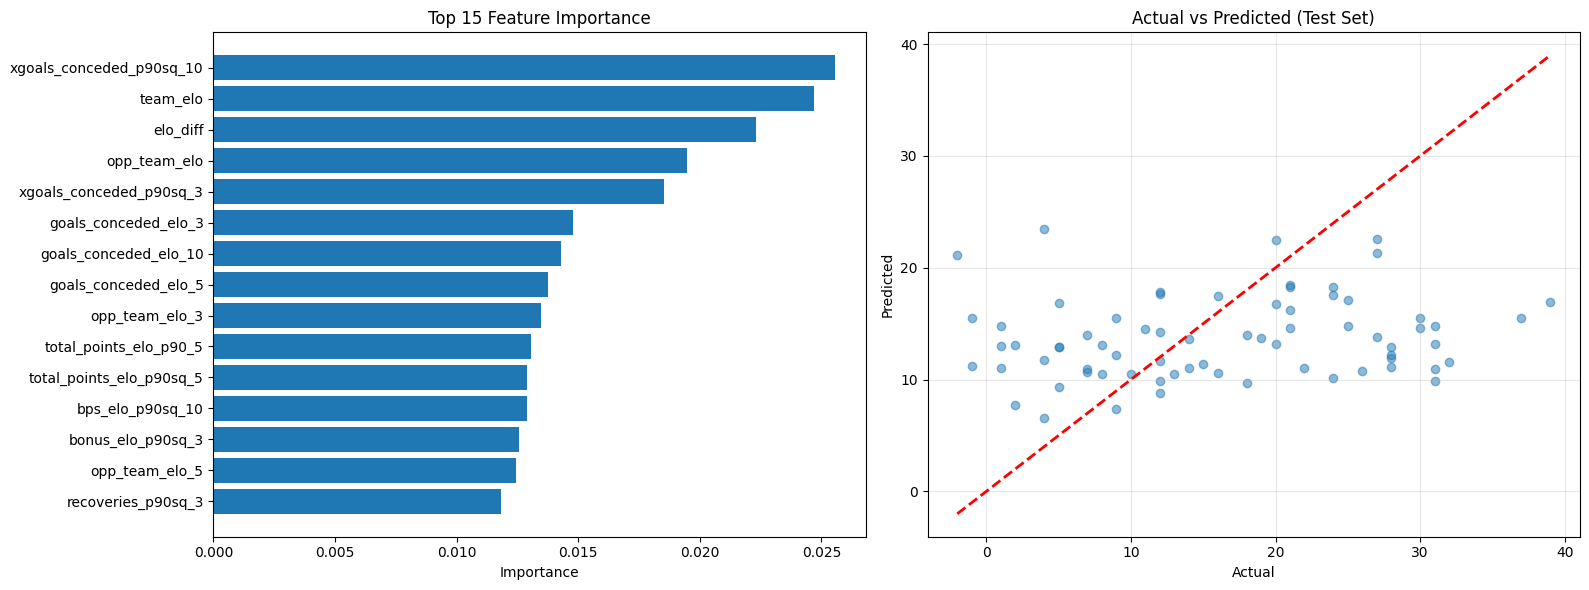

In [85]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 346/3961

Training Set Performance:
R² Score: 0.8086
RMSE: 0.7302
MAE: 0.5946

Test Set Performance:
R² Score: -0.1177
RMSE: 1.9459
MAE: 1.5888

Top 20 Feature Importances:
                feature  importance
    recoveries_p90sq_10    0.025972
         opp_team_elo_3    0.025435
  opp_team_elo_p90sq_10    0.020190
   opp_team_elo_p90sq_5    0.019862
 opp_team_elo_elo_p90_5    0.017303
               elo_diff    0.016278
     recoveries_p90sq_3    0.014941
             team_elo_5    0.014278
    recoveries_p90sq_at    0.013485
       team_elo_p90sq_5    0.013179
     team_elo_elo_p90_5    0.012522
 opp_team_elo_elo_p90_3    0.011816
      recoveries_p90_at    0.011778
   opp_team_elo_p90sq_3    0.011605
 goals_conceded_p90sq_5    0.011567
goals_conceded_p90sq_at    0.011007
             team_elo_3    0.010972
           opp_team_elo    0.010292
xgoals_conceded_p90sq_3    0.009974
         opp_team_elo_5    0.009837


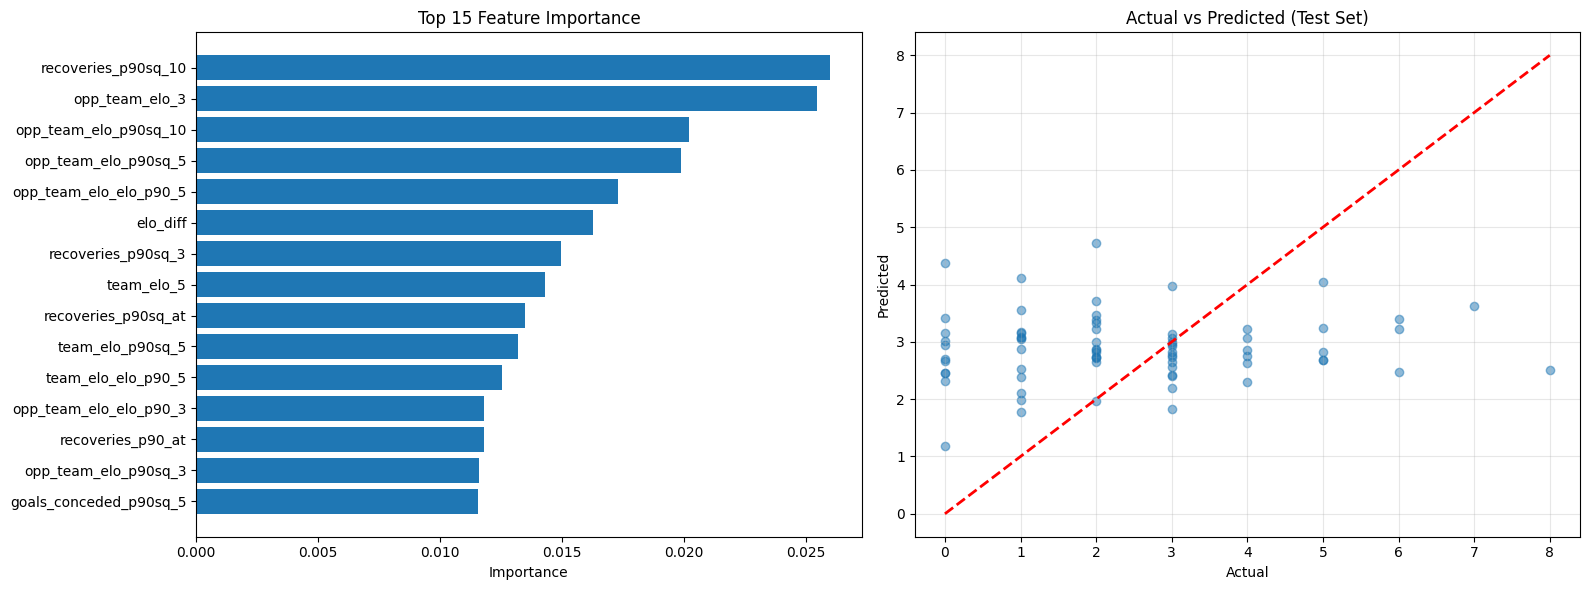

In [86]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
    data=df[filtered],
    target='saves_per90',
    positions={'GK'})
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 394/4872

Training Set Performance:
R² Score: 0.8082
RMSE: 1.2527
MAE: 0.9866

Test Set Performance:
R² Score: 0.0040
RMSE: 2.5967
MAE: 1.9915

Top 20 Feature Importances:
                feature  importance
         xassists_elo_3    0.036537
   opp_team_elo_p90sq_5    0.034459
               team_elo    0.031724
        xassists_p90_10    0.018068
  clean_sheets_p90sq_at    0.017496
             xassists_3    0.014159
   defensive_cont_elo_3    0.013208
         opp_team_elo_5    0.012864
      xassists_p90sq_10    0.010073
  goals_conceded_p90_10    0.009843
goals_conceded_p90sq_at    0.009406
  goals_scored_p90sq_at    0.009370
            bps_p90sq_5    0.009328
            team_elo_10    0.009287
      xassists_p90sq_at    0.008311
        opp_team_elo_10    0.008216
           opp_team_elo    0.007914
       recoveries_elo_3    0.007769
         xassists_elo_5    0.007194
         bonus_p90sq_at    0.0071

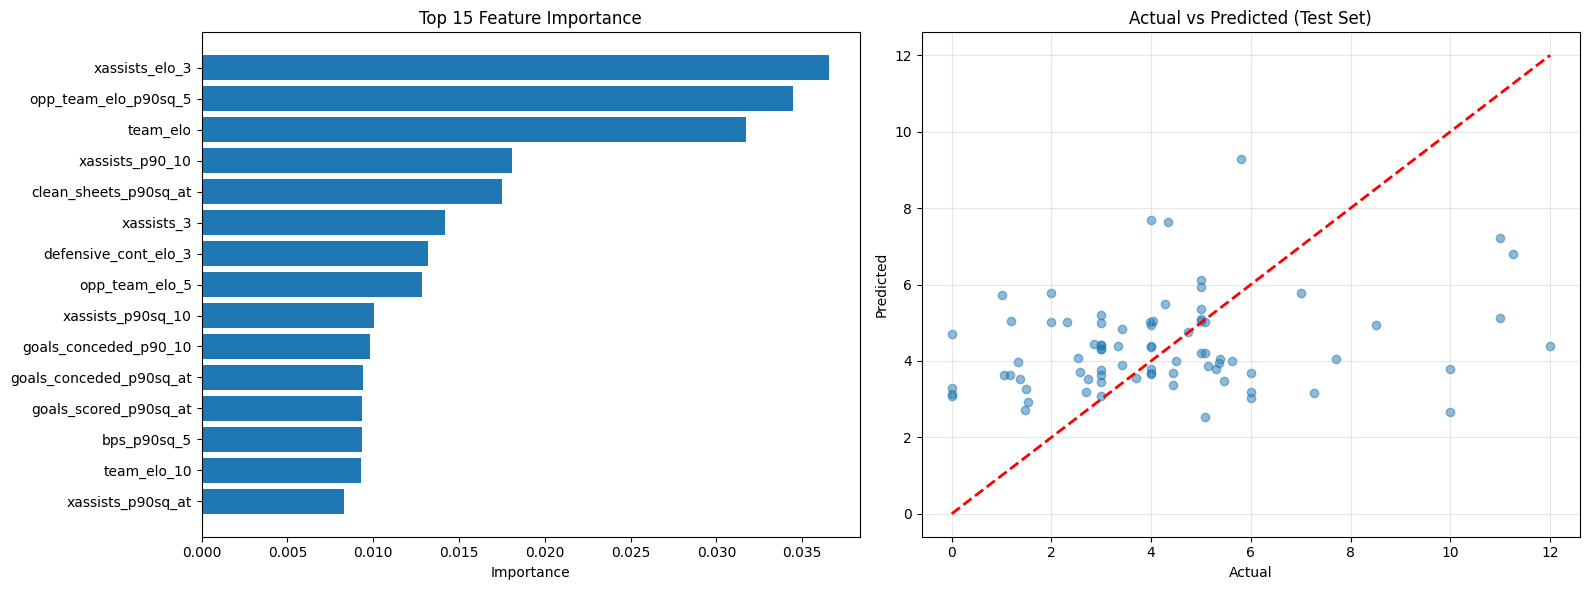

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 1814/20112

Training Set Performance:
R² Score: 0.7998
RMSE: 1.8403
MAE: 1.4940

Test Set Performance:
R² Score: 0.1333
RMSE: 3.8623
MAE: 2.9479

Top 20 Feature Importances:
                                   feature  importance
                   defensive_cont_p90sq_at    0.055813
                   defensive_cont_p90sq_10    0.038510
                     defensive_cont_p90_10    0.035800
                                cbi_p90_10    0.025291
                                tackles_at    0.019552
xgoal_involvements_x_defensive_cont_p90_at    0.011320
                              opp_team_elo    0.011076
                           xgoals_p90sq_10    0.008009
                                    cbi_at    0.007375
                         xassists_p90sq_at    0.006900
                           opp_team_elo_10    0.006815
                         defensive_cont_10    0.006676
               xgoal_involvements_p9

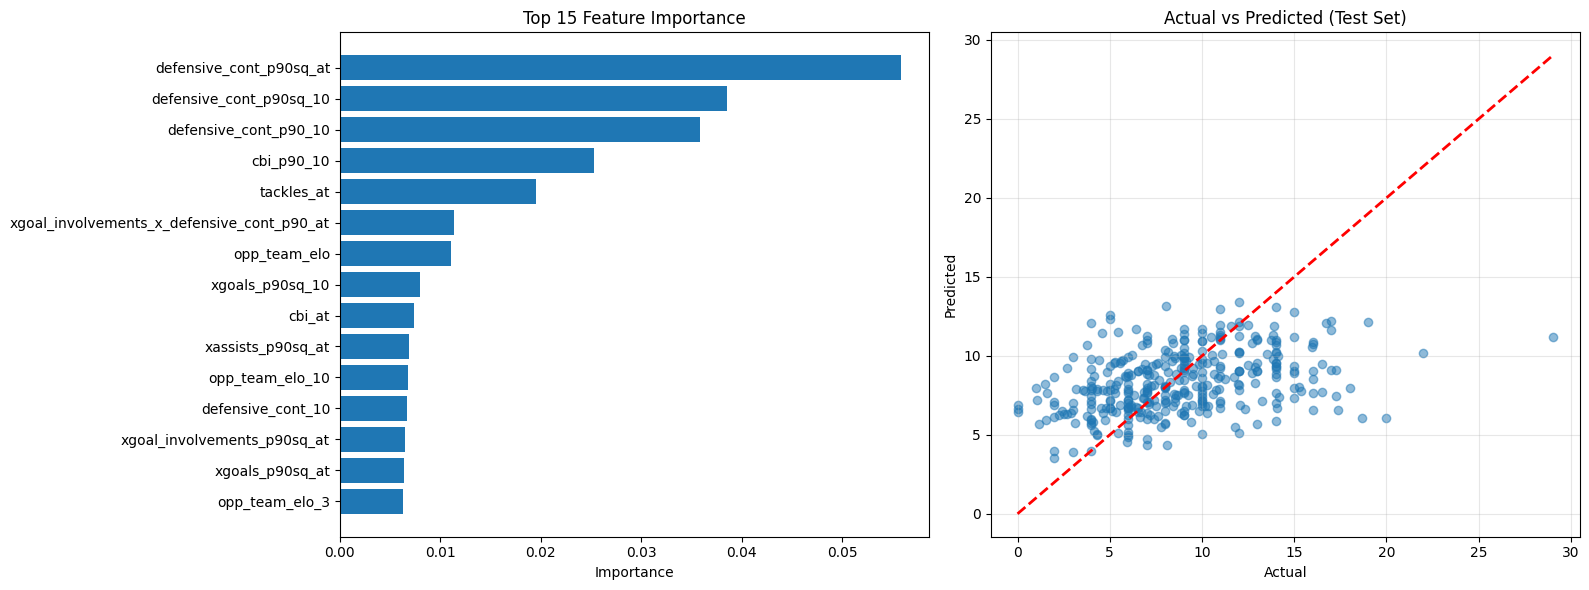

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 1496/17018

Training Set Performance:
R² Score: 0.7584
RMSE: 1.9578
MAE: 1.5764

Test Set Performance:
R² Score: 0.0497
RMSE: 3.5923
MAE: 2.9122

Top 20 Feature Importances:
                                   feature  importance
                               cbi_p90sq_3    0.030183
                               cbi_p90sq_5    0.024239
                                     cbi_5    0.015078
                    defensive_cont_p90sq_5    0.014629
                    opp_team_elo_elo_p90_5    0.012764
                              cbi_p90sq_10    0.010922
                              opp_team_elo    0.010565
                             recoveries_10    0.010453
                                     cbi_3    0.010396
                                    cbi_at    0.010168
                       xassists_elo_p90_10    0.009992
                    defensive_cont_p90sq_3    0.009822
                             recover

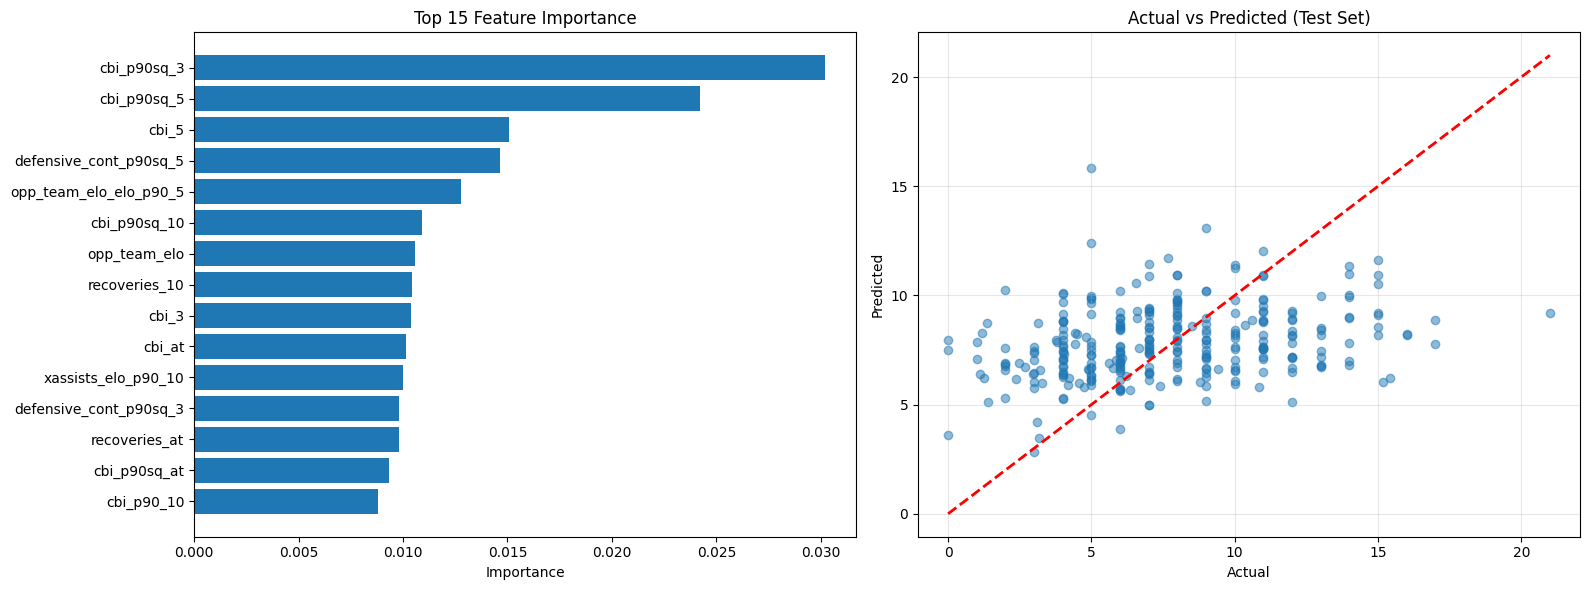

In [87]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'FWD'})
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'MID'})
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'DEF'})
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

Goals conceded per 90
Estimated λ (mean goals per match): 1.350


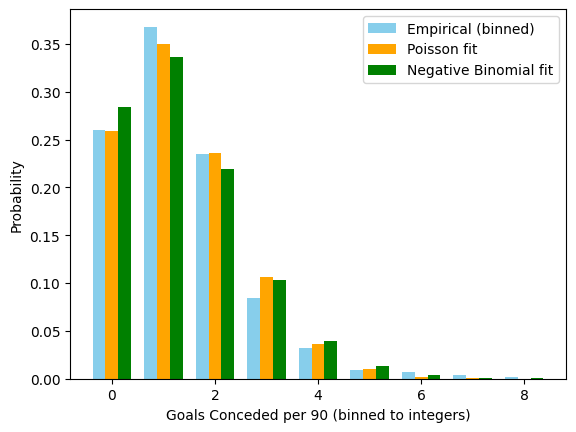

Mean: 1.342, Variance: 1.520
Overdispersion ratio (Var/Mean): 1.133
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.259


In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
df['xgc_p90'] = (df['expected_goals_conceded'] / df['minutes']) * 90

# Filter to reasonable samples
data = df[(df['minutes'] > 0) & (df['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.319


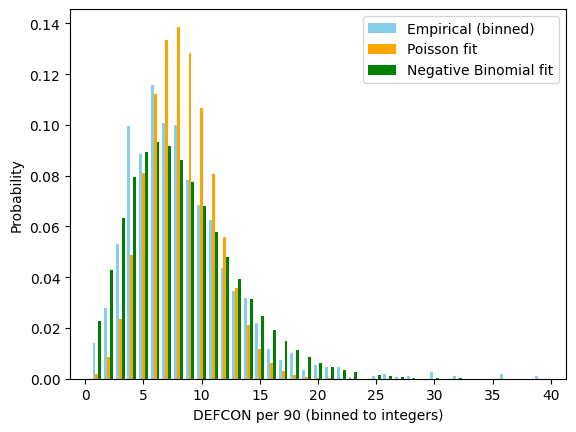

Mean: 8.313, Variance: 21.817
Overdispersion ratio (Var/Mean): 2.624
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [89]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean defcon per 90): 3.210


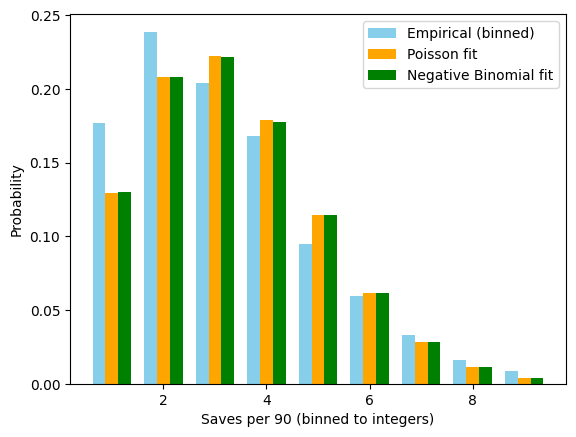

Mean: 3.210, Variance: 3.241
Overdispersion ratio (Var/Mean): 1.009
✅ Poisson assumption looks reasonable.


In [90]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.326e+04
Date:                Sun, 04 Jan 2026   Prob (F-statistic):                        0.00
Time:                        20:13:35   Log-Likelihood:                         -38676.
No. Observations:               41038   AIC:                                  7.735e+04
Df Residuals:                   41037   BIC:                                  7.736e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

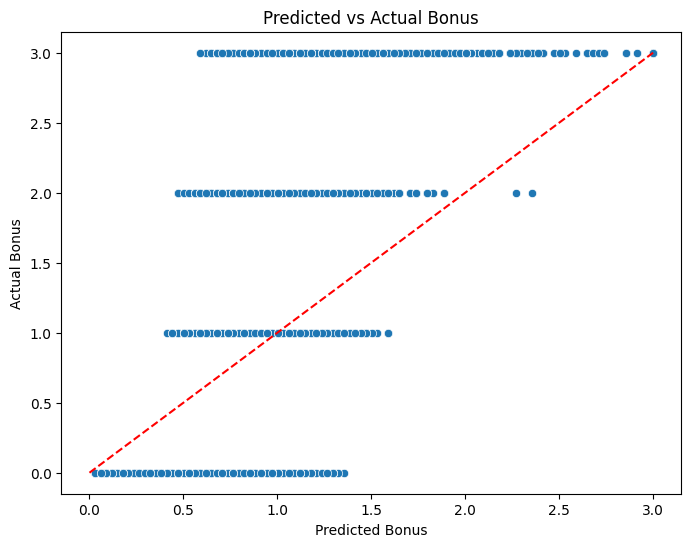

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459433  0.230699  1.106162  1.947910
FWD           0.332716  0.199160  1.047771  1.710154
GK            0.491317  0.246263  1.115019  2.011726
GKP                NaN       NaN       NaN       NaN
MID           0.395401  0.245532  1.049928  1.822966


C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\2893669323.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = df.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [91]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
filtered = (df['minutes']>45) & (df['bonus']>=0) & (df['bps']>0) & (df['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=df[filtered]).fit()
print(model.summary())

df['bonus_pred'] = model.predict(df[filtered])
df['bonus_pred'] = np.clip(df['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=df)
plt.plot([df['bonus'].min(), df['bonus'].max()],
         [df['bonus'].min(), df['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = df.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [92]:
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [93]:
prediction_data.pivot_table(index='event',values='minutes',aggfunc='count')

,minutes
event,
21.0,0
22.0,0
23.0,0
24.0,0
25.0,0
26.0,0
27.0,0
28.0,0
29.0,0


In [94]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [95]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    8640.000000
mean       55.675247
std        19.424097
min        15.717931
25%        38.691802
50%        55.949816
75%        71.536443
max        90.000000
Name: mins_pred, dtype: float64

In [96]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    8100.000000
mean        0.181408
std         0.140810
min         0.020439
25%         0.058804
50%         0.151731
75%         0.259952
max         1.013520
Name: xgp90_pred, dtype: float64

In [97]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    8100.000000
mean        0.103986
std         0.072437
min         0.016164
25%         0.050141
50%         0.085651
75%         0.135266
max         0.467601
Name: xap90_pred, dtype: float64

In [98]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    8640.000000
mean        1.481995
std         0.313629
min         0.521928
25%         1.282704
50%         1.484844
75%         1.691474
max         2.376754
Name: xgcp90_pred, dtype: float64

In [99]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    8640.000000
mean       16.722005
std         4.181985
min         1.355240
25%        14.037622
50%        16.783130
75%        19.244386
max        33.799959
Name: xbpsp90_pred, dtype: float64

In [100]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    540.000000
mean       3.029299
std        0.579960
min        1.319993
25%        2.745281
50%        3.072011
75%        3.343015
max        4.557633
Name: xsavesp90_pred, dtype: float64

In [101]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    8100.000000
mean        7.841090
std         1.872629
min         3.046971
25%         6.750703
50%         7.959182
75%         9.054340
max        12.939081
Name: xdefconp90_pred, dtype: float64

In [102]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129936,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,22.0,Sunderland,1055.998941,82.020155,0.123246,0.131898,1.426807
129964,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,23.0,Chelsea,1125.185589,82.020155,0.118543,0.132260,1.556511
129966,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,21.0,Aston Villa,1176.220613,82.020155,0.118543,0.131732,1.597085
129967,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,24.0,Nott'm Forest,1015.357881,82.020155,0.124522,0.136271,1.056846
129968,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,25.0,Brighton,1079.572149,82.020155,0.121884,0.130412,1.877833


In [103]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
136205,Hugo Ekitiké,661.0,91.0,Liverpool,FWD,20252026.0,21.0,Arsenal,1260.148901,68.511058,1.013520,0.108725,1.871953
131594,Chris Wood,525.0,72.0,Nott'm Forest,FWD,20252026.0,21.0,West Ham,968.231321,32.842355,0.677718,0.067531,1.511014
143498,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,21.0,Aston Villa,1176.220613,32.520700,0.644377,0.112839,1.787201
131020,Ashley Barnes,218.0,42.0,Burnley,FWD,20252026.0,21.0,Man Utd,1060.843658,37.280515,0.561837,0.080970,1.919309
147313,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,21.0,Leeds,963.383402,49.460817,0.553966,0.048720,1.422878
139343,Kai Havertz,30.0,73.0,Arsenal,FWD,20252026.0,21.0,Liverpool,1192.233319,43.730405,0.549029,0.056984,1.463346
135281,Gabriel Fernando de Jesus,31.0,64.0,Arsenal,FWD,20252026.0,21.0,Liverpool,1192.233319,26.213178,0.543560,0.043991,1.531536
140996,Marc Guiu Paz,252.0,43.0,Chelsea,FWD,20252026.0,21.0,Fulham,1048.275375,47.086300,0.536316,0.055699,1.417215
143410,Norberto Bercique Gomes Betuncal,311.0,50.0,Everton,FWD,20252026.0,21.0,Wolves,897.754426,27.385187,0.520352,0.038321,1.281550
130262,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,21.0,Arsenal,1260.148901,53.268440,0.514241,0.058681,2.087643


In [104]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [105]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [106]:
scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] >= 60:
            return 2
        elif x['mins_pred'] > 0:
            return 1
        else:
            return 0
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\282654768.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_15908\282654768.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_

In [107]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]
predictions

,player_name_id,team_name,team_elo,element,position,opp_team_name,opp_team_elo,season,value,event,...,xgcp90_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
129739,Aaron Hickey,Brentford,1057.885583,116.0,DEF,Sunderland,1055.998941,20252026.0,40.0,21.0,...,1.533124,1,0.094568,0.039076,0.863441,0.000000,-0.528207,0.556698,0.381162,2.406737
129741,Aaron Hickey,Brentford,1057.885583,116.0,DEF,Chelsea,1125.185589,20252026.0,40.0,22.0,...,1.540797,1,0.103634,0.041758,0.856841,0.000000,-0.531866,0.556698,0.284936,2.312000
129743,Aaron Hickey,Brentford,1057.885583,116.0,DEF,Nott'm Forest,1015.357881,20252026.0,40.0,23.0,...,1.438378,1,0.082663,0.034028,0.949249,0.000000,-0.483266,0.556698,0.431867,2.571238
129746,Aaron Hickey,Brentford,1057.885583,116.0,DEF,Aston Villa,1176.220613,20252026.0,40.0,24.0,...,1.552882,1,0.101566,0.041455,0.846548,0.000000,-0.537635,0.556698,0.269720,2.278352
129747,Aaron Hickey,Brentford,1057.885583,116.0,DEF,Newcastle,1092.044885,20252026.0,40.0,25.0,...,1.555276,1,0.098460,0.040098,0.844525,0.000000,-0.538778,0.556698,0.351138,2.352140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147895,Đorđe Petrović,Bournemouth,1035.902983,67.0,GK,Wolves,897.754426,20252026.0,45.0,24.0,...,1.533512,2,NaN,NaN,0.863106,0.589244,-0.528392,0.000000,0.291364,3.215322
147897,Đorđe Petrović,Bournemouth,1035.902983,67.0,GK,Aston Villa,1176.220613,20252026.0,45.0,25.0,...,1.666822,2,NaN,NaN,0.755385,0.636854,-0.592319,0.000000,0.260055,3.059976
147899,Đorđe Petrović,Bournemouth,1035.902983,67.0,GK,Everton,1064.440263,20252026.0,45.0,26.0,...,1.557854,2,NaN,NaN,0.842350,0.625178,-0.540010,0.000000,0.269257,3.196776
147901,Álex Jiménez Sánchez,Bournemouth,1035.902983,713.0,DEF,Aston Villa,1176.220613,20252026.0,45.0,25.0,...,1.304902,2,0.124353,0.179340,1.084796,0.000000,-0.420838,0.556698,0.307905,3.832254


In [108]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>60)
    #&(prediction_data['position'].isin(['MID','FWD']))
    ][["player_name_id","element","value","team_name","position","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xdefconp90_pred','xbpsp90_pred','xpoints'
    ]].sort_values(by='xpoints',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xdefconp90_pred,xbpsp90_pred,xpoints
136205,Hugo Ekitiké,661.0,91.0,Liverpool,FWD,21.0,Arsenal,1260.148901,68.511058,1.013520,0.108725,7.233696,23.766640,6.303396
145232,Ryan Gravenberch,390.0,57.0,Liverpool,MID,21.0,Arsenal,1260.148901,77.686320,0.513395,0.152222,9.855188,19.220065,5.905984
137217,James Garner,303.0,51.0,Everton,MID,21.0,Wolves,897.754426,80.554939,0.368132,0.181083,10.660836,27.176633,5.766857
144432,Rayan Cherki,417.0,68.0,Man City,MID,21.0,Brighton,1079.572149,68.658411,0.266081,0.356048,8.734559,26.481100,5.453765
143111,Nico O'Reilly,411.0,53.0,Man City,DEF,21.0,Brighton,1079.572149,72.999455,0.090547,0.069201,6.552109,20.044945,5.305291
139107,Joško Gvardiol,403.0,61.0,Man City,DEF,21.0,Brighton,1079.572149,62.831552,0.113527,0.055300,9.190151,24.575979,5.291092
141595,Matheus Santos Carneiro da Cunha,450.0,82.0,Man Utd,MID,21.0,Burnley,879.484744,75.162868,0.316001,0.164477,7.288486,18.950518,5.210684
144211,Phil Foden,414.0,89.0,Man City,MID,21.0,Brighton,1079.572149,77.337864,0.261276,0.188671,6.738577,23.360087,5.185365
141561,Matheus Nunes,407.0,54.0,Man City,DEF,21.0,Brighton,1079.572149,74.933936,0.080239,0.151570,9.170512,19.387805,5.174751
141230,Marcus Tavernier,84.0,56.0,Bournemouth,MID,21.0,Spurs,1013.601890,77.707086,0.345398,0.111457,7.978512,19.675397,5.122015


In [109]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640 entries, 0 to 8639
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          8640 non-null   object 
 1   team_name               8640 non-null   object 
 2   team_elo                8640 non-null   float64
 3   element                 8640 non-null   float64
 4   position                8640 non-null   object 
 5   opp_team_name           8640 non-null   object 
 6   opp_team_elo            8640 non-null   float64
 7   season                  8640 non-null   float64
 8   value                   8640 non-null   float64
 9   event                   8640 non-null   float64
 10  mins_pred               8640 non-null   float64
 11  xgp90_pred              8100 non-null   float64
 12  xap90_pred              8100 non-null   float64
 13  xgcp90_pred             8640 non-null   float64
 14  xpoints_mins            8640 non-null   

In [110]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [111]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [112]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 21 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
136205,Hugo Ekitiké,661.0,21.0,91.0,Liverpool,FWD,Arsenal,1260.148901,68.511058,2,3.086102,0.248296,0.000000,0.0,0.000000,0.270258,0.698739,6.303396
145232,Ryan Gravenberch,390.0,21.0,57.0,Liverpool,MID,Arsenal,1260.148901,77.686320,2,2.215764,0.394184,0.220970,0.0,0.000000,0.509995,0.565070,5.905984
137217,James Garner,303.0,21.0,51.0,Everton,MID,Wolves,897.754426,80.554939,2,1.647494,0.486237,0.324139,0.0,0.000000,0.509995,0.798993,5.766857
144432,Rayan Cherki,417.0,21.0,68.0,Man City,MID,Brighton,1079.572149,68.658411,2,1.014927,0.814857,0.335442,0.0,0.000000,0.509995,0.778544,5.453765
143111,Nico O'Reilly,411.0,21.0,53.0,Man City,DEF,Brighton,1079.572149,72.999455,2,0.440658,0.168388,1.759281,0.0,-0.209055,0.556698,0.589321,5.305291
139107,Joško Gvardiol,403.0,21.0,61.0,Man City,DEF,Brighton,1079.572149,62.831552,2,0.475538,0.115820,1.654638,0.0,-0.234135,0.556698,0.722534,5.291092
141595,Matheus Santos Carneiro da Cunha,450.0,21.0,82.0,Man Utd,MID,Burnley,879.484744,75.162868,2,1.319531,0.412085,0.411927,0.0,0.000000,0.509995,0.557145,5.210684
144211,Phil Foden,414.0,21.0,89.0,Man City,MID,Brighton,1079.572149,77.337864,2,1.122586,0.486380,0.379617,0.0,0.000000,0.509995,0.686787,5.185365
141561,Matheus Nunes,407.0,21.0,54.0,Man City,DEF,Brighton,1079.572149,74.933936,2,0.400840,0.378592,1.534466,0.0,-0.265846,0.556698,0.570001,5.174751
141230,Marcus Tavernier,84.0,21.0,56.0,Bournemouth,MID,Spurs,1013.601890,77.707086,2,1.491104,0.288701,0.253759,0.0,0.000000,0.509995,0.578457,5.122015


In [113]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW21 - GW25


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
169,Hugo Ekitiké,340.522702,10,13.991658,1.322404,0.000000,0.0,0.000000,1.351288,3.536354,30.201704
408,Ryan Gravenberch,395.721373,10,11.426607,1.643813,1.293597,0.0,0.000000,2.549973,3.166174,30.080165
353,Nico O'Reilly,363.340589,10,2.534530,0.927474,10.055947,0.0,-0.815424,2.783488,2.930484,28.416497
310,Matheus Nunes,374.172904,10,2.468952,1.854551,9.339475,0.0,-0.970430,2.783488,2.911881,28.387916
387,Rayan Cherki,343.292055,10,5.065469,4.109414,2.175655,0.0,0.000000,2.549973,4.048875,27.949386
245,Joško Gvardiol,310.766625,10,2.506267,0.603752,9.360470,0.0,-0.950145,2.783488,3.642454,27.946286
197,James Garner,402.774697,10,7.893752,2.155019,1.265008,0.0,0.000000,2.549973,3.708212,27.571964
19,Andrew Robertson,315.301415,10,6.911549,1.568558,5.277747,0.0,-2.209264,2.783488,2.962518,27.294596
381,Phil Foden,387.387524,10,5.955220,2.461620,2.226779,0.0,0.000000,2.549973,3.370021,26.563613
411,Rúben dos Santos Gato Alves Dias,410.562450,10,1.405799,0.393679,9.747570,0.0,-0.854200,2.783488,2.903710,26.380047


In [114]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
408,Ryan Gravenberch,1433.172439,36,41.184503,5.630436,4.674782,0.0,0.000000,9.179903,11.869402,108.539026
169,Hugo Ekitiké,1233.535238,36,49.637852,4.543737,0.000000,0.0,0.000000,4.864638,12.649743,107.695970
310,Matheus Nunes,1345.095124,36,8.534590,6.875587,33.470349,0.0,-3.542890,10.020555,10.458373,101.816564
353,Nico O'Reilly,1307.816096,36,8.973522,3.366343,35.939233,0.0,-3.010929,10.020555,10.475419,101.764144
19,Andrew Robertson,1132.150084,36,25.121429,5.341638,19.988548,0.0,-7.472862,10.020555,11.722552,100.721860
387,Rayan Cherki,1233.827583,36,18.300335,14.739730,7.692386,0.0,0.000000,9.179903,14.438503,100.350858
245,Joško Gvardiol,1123.156110,36,8.987064,2.228025,33.389138,0.0,-3.502256,10.020555,13.043716,100.166242
197,James Garner,1447.087419,36,28.132227,7.656936,4.320171,0.0,0.000000,9.179903,13.184958,98.474195
244,Joël Veltman,1122.972594,36,24.629498,4.767758,18.162716,0.0,-8.582352,10.020555,10.161880,95.160055
381,Phil Foden,1391.762333,36,21.165128,8.806424,7.864704,0.0,0.000000,9.179903,12.058326,95.074485


In [115]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': picks_current_gameweek
})

In [116]:
# # Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [117]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
            pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
            pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
            pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
            pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves 
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [118]:
# Step 1: Insert new predictions that don't exist yet
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, 
    opp_team_elo, value, event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,  -- Add these explicitly
    fixture, total_points, minutes, goals_scored, assists, bonus, 
    bps, clean_sheets, goals_conceded, was_home, expected_assists, 
    expected_goal_involvements, expected_goals, expected_goals_conceded, 
    starts, cbi, defensive_contribution, recoveries, tackles, saves
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, 
    p.opp_team_name, p.opp_team_elo, p.value, p.event, p.season, 
    p.xpoints, p.prediction_timestamp, p.prediction_gameweek,  -- Include new columns
    pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, 
    pg.bonus, pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, 
    pg.expected_assists, pg.expected_goal_involvements, pg.expected_goals, 
    pg.expected_goals_conceded, pg.starts, pg.cbi, pg.defensive_contribution, 
    pg.recoveries, pg.tackles, pg.saves
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season
WHERE NOT EXISTS (
    SELECT 1 
    FROM predictions_allgws pa 
    WHERE pa.player_name_id = p.player_name_id 
        AND pa.event = p.event 
        AND pa.season = p.season
);
""")

In [119]:
# # Step 1: Insert new predictions that don't exist yet
# db_creator.execute_sql("""
# INSERT INTO predictions_allgws
# SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
# FROM predictions p
# LEFT JOIN playergw pg 
#     ON p.player_name_id = pg.player_name_id 
#     AND p.event = pg.event 
#     AND p.season = pg.season
# WHERE NOT EXISTS (
#     SELECT 1 
#     FROM predictions_allgws pa 
#     WHERE pa.player_name_id = p.player_name_id 
#         AND pa.event = p.event 
#         AND pa.season = p.season
# );
# """)

# # Step 2: Update existing predictions with actual results (where total_points is still NULL)
# db_creator.execute_sql("""
# UPDATE predictions_allgws
# SET 
#     fixture = pg.fixture,
#     total_points = pg.total_points,
#     minutes = pg.minutes,
#     goals_scored = pg.goals_scored,
#     assists = pg.assists,
#     bonus = pg.bonus,
#     bps = pg.bps,
#     clean_sheets = pg.clean_sheets,
#     goals_conceded = pg.goals_conceded,
#     expected_assists = pg.expected_assists,
#     expected_goal_involvements = pg.expected_goal_involvements,
#     expected_goals = pg.expected_goals,
#     expected_goals_conceded = pg.expected_goals_conceded,
#     starts = pg.starts,
#     cbi = pg.cbi,
#     defensive_contribution = pg.defensive_contribution,
#     recoveries = pg.recoveries,
#     tackles = pg.tackles,
#     saves = pg.saves
# FROM playergw pg
# WHERE predictions_allgws.player_name_id = pg.player_name_id
#     AND predictions_allgws.event = pg.event
#     AND predictions_allgws.season = pg.season
#     AND predictions_allgws.total_points IS NULL;  -- Only update rows without actual points yet
# """)

# print(f"Successfully added/updated gameweek {picks_current_gameweek} predictions in predictions_allgws")

In [120]:
# # # Create predictions_allgws if it doesn't exist, otherwise append
# # # creates new rows every time the script is loaded
# # db_creator.execute_sql("""
# #     CREATE TABLE IF NOT EXISTS predictions_allgws AS
# #     SELECT * FROM predictions WHERE 1=0;  -- Creates empty table with same schema, 1=0 ensures no data copied, just structure
    
# #     INSERT INTO predictions_allgws
# #     SELECT * FROM predictions;
# # """)

# # Create predictions_allgws if it doesn't exist
# db_creator.execute_sql("""
#     CREATE TABLE IF NOT EXISTS predictions_allgws AS
#     SELECT p.*,
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves 
            
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season
#     WHERE 1=0;  -- Empty table with correct schema
# """)

# # Insert new predictions from current gameweek
# db_creator.execute_sql("""
#     INSERT INTO predictions_allgws
#     SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
                       
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season;
# """)

# print(f"Successfully added gameweek {picks_current_gameweek} predictions to predictions_allgws")

In [121]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (view['prediction_gameweek']==16)
view[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes
0,Gabriel dos Santos Magalhães,17.0,20252026.0,NaN,NaN
1,Gabriel dos Santos Magalhães,18.0,20252026.0,NaN,NaN
2,Gabriel dos Santos Magalhães,19.0,20252026.0,NaN,NaN
3,Gabriel dos Santos Magalhães,20.0,20252026.0,NaN,NaN
4,Gabriel dos Santos Magalhães,21.0,20252026.0,NaN,NaN


In [122]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes
179062,Erling Haaland,13.0,20252026.0,2.0,90.0
179063,Erling Haaland,14.0,20252026.0,14.0,90.0
179064,Erling Haaland,15.0,20252026.0,2.0,68.0
179065,Erling Haaland,16.0,20252026.0,13.0,90.0
179066,Erling Haaland,17.0,20252026.0,16.0,90.0


In [123]:
view = db_creator.table_to_df('predictions')
future_filter = (view['season']==20252026)&(view['event']<=20)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','xpoints']][future_filter]

,player_name_id,event,season,xpoints


In [124]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points','minutes']][
    (view['season']==20252026)&(
    view['event']<=17)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points,minutes
5808,Erling Haaland,2025-12-18 14:48:05.460857,17.0,5.932372,NaN,NaN


In [125]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=13)&(
                df_preds['event']<=20)&(
            df_preds['season']==20252026)&(
            df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2025-12-18 14:48:05.460857 16                  20252026.0 17.0   5.932372
                                                          18.0   5.875096
                                                          19.0   5.898596
                                                          20.0   5.844356

Correlation: nan
Mean Absolute Error: nan
Root Mean Squared Error: nan


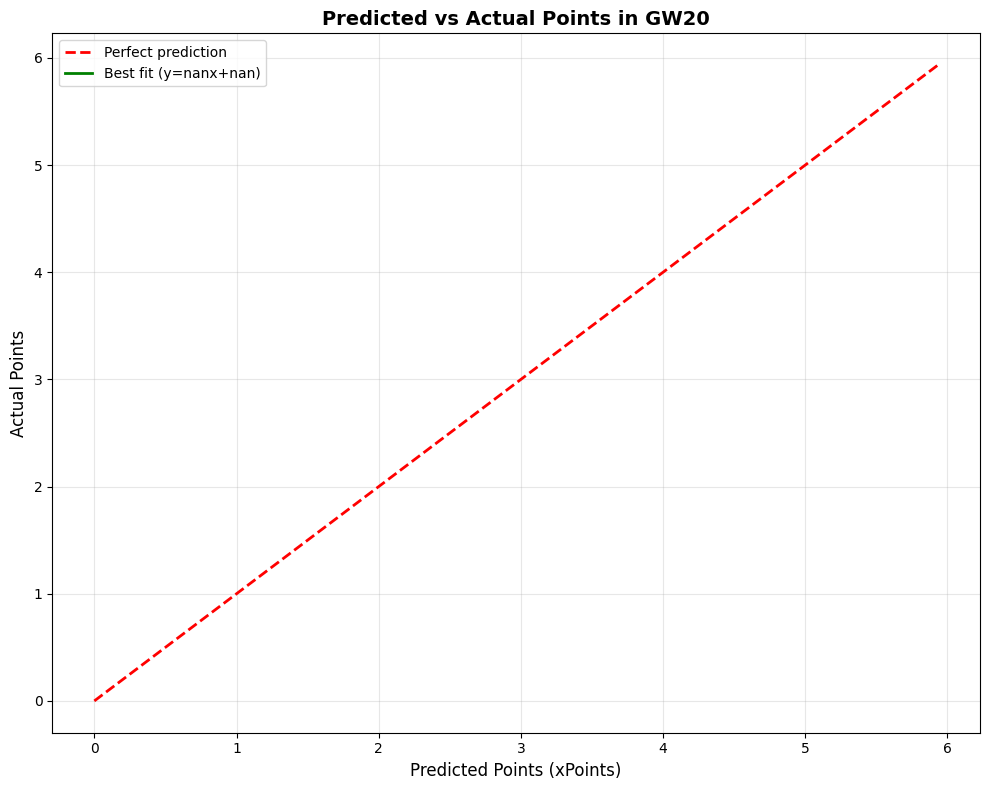

In [126]:
# Create the plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# Add a diagonal reference line (perfect predictions)
max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# Add regression line showing actual correlation
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

plt.xlabel('Predicted Points (xPoints)', fontsize=12)
plt.ylabel('Actual Points', fontsize=12)
plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [127]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 2.54 minute(s)
